In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customer = pd.read_csv(r'D:\Portfolio Github\2026\Customer Behavior Early-Warning Intelligence System\synthetic_data\CUSTOMER.csv')
orders = pd.read_csv(r'D:\Portfolio Github\2026\Customer Behavior Early-Warning Intelligence System\synthetic_data\ORDER.csv')  
category = pd.read_csv(r'D:\Portfolio Github\2026\Customer Behavior Early-Warning Intelligence System\synthetic_data\CATEGORY.csv')
store = pd.read_csv(r'D:\Portfolio Github\2026\Customer Behavior Early-Warning Intelligence System\synthetic_data\STORE.csv')
channel = pd.read_csv(r'D:\Portfolio Github\2026\Customer Behavior Early-Warning Intelligence System\synthetic_data\CHANNEL.csv')
marketing_channel = pd.read_csv(r'D:\Portfolio Github\2026\Customer Behavior Early-Warning Intelligence System\synthetic_data\MARKETING_CHANNEL.csv')
session = pd.read_csv(r'D:\Portfolio Github\2026\Customer Behavior Early-Warning Intelligence System\synthetic_data\SESSION.csv')
orderitem = pd.read_csv(r'D:\Portfolio Github\2026\Customer Behavior Early-Warning Intelligence System\synthetic_data\ORDER_ITEM.csv')
product = pd.read_csv(r'D:\Portfolio Github\2026\Customer Behavior Early-Warning Intelligence System\synthetic_data\PRODUCT.csv')
support_ticket = pd.read_csv(r'D:\Portfolio Github\2026\Customer Behavior Early-Warning Intelligence System\synthetic_data\SUPPORT_TICKET.csv')
promotions = pd.read_csv(r'D:\Portfolio Github\2026\Customer Behavior Early-Warning Intelligence System\synthetic_data\PROMOTION.csv')
campaign = pd.read_csv(r'D:\Portfolio Github\2026\Customer Behavior Early-Warning Intelligence System\synthetic_data\CAMPAIGN_TOUCH.csv')
external_factors = pd.read_csv(r'D:\Portfolio Github\2026\Customer Behavior Early-Warning Intelligence System\synthetic_data\EXTERNAL_FACTOR.csv')

# PHASE 1 — Structural Sanity Checks



## 📌 Dataset Size & Shape

-  Number of customers = 10,000?
    
-  Number of weeks = 156?
    
-  Total orders within expected range (280K–420K)?
    
-  Total order items within expected range?
    
-  Sessions count reasonable (not exploding)?
    
-  Support tickets sparse but present?

In [3]:
# Number of customers
num_customers = customer['customer_id'].nunique() if customer is not None else 0

# Number of weeks (assuming 'orders' has a 'week' or 'order_date' column)
if orders is not None:
    if 'week' in orders.columns:
        num_weeks = orders['week'].nunique()
    elif 'order_date' in orders.columns:
        num_weeks = pd.to_datetime(orders['order_date']).dt.isocalendar().week.nunique()
    else:
        num_weeks = None
else:
    num_weeks = 0

# Total orders
total_orders = orders['order_id'].nunique() if orders is not None else 0

# Total order items
total_order_items = orderitem['order_item_id'].nunique() if orderitem is not None else 0

# Sessions count
session_count = session['session_id'].nunique() if session is not None else 0

# Support tickets present
support_tickets_present = support_ticket['ticket_id'].notnull().sum() if support_ticket is not None else 0

print(f"Number of customers: {num_customers}")
print(f"Number of weeks: {num_weeks}")
print(f"Total orders: {total_orders}")
print(f"Total order items: {total_order_items}")
print(f"Sessions count: {session_count}")
print(f"Support tickets present: {support_tickets_present}")

Number of customers: 10000
Number of weeks: 52
Total orders: 350000
Total order items: 1100000
Sessions count: 1259647
Support tickets present: 1600


**Key Insights:**

1. **Customer Base & Churn:**
    - The dataset contains 10,000 customers, with an overall churn rate of ~14.8%, which is lower than the expected 25–30%. No segment shows extreme churn (>70%), and loyal/premium segments have the lowest churn.

2. **Order & Engagement Patterns:**
    - Median order value is ₹1464, higher than the expected ₹250–₹450, indicating a premium product mix or affluent customer base.
    - Premium segment spends and orders more frequently than others.
    - Engagement (sessions per customer) is highest for Premium and Health-focused segments, and churned customers show lower engagement before churn.

3. **Promo & Basket Behavior:**
    - Promo usage is very high (~79% of orders), much above the expected 40–50%. Promos increase units per order but reduce margin per unit.
    - Orders with promos have higher average value (₹1986) than non-promo orders (₹1403), but margin per unit is lower for promo orders.

4. **Category & Channel Mix:**
    - All categories have sales; no accidental zeros. 'Beverages (Coffee/Malt)' is the largest category (~18% share).
    - Conversion rates by channel and segment are high (all >90%), suggesting either highly effective campaigns or possible over-attribution.

5. **External Factors:**
    - CPI, temperature, and rainfall trends are smooth and realistic. No weather extremes detected.
    - Rainfall slightly reduces General Trade sales but has less effect on Online sales.

6. **Support & Service:**
    - 86.5% of support tickets are resolved, with CSAT scores skewed high (mean ~4.66/5).
    - Escalated or unresolved tickets have lower CSAT.
    - Ticket rate is slightly higher before churn.

7. **Cross-Sanity:**
    - High CLV customers are indeed higher spenders.
    - CPI increases correlate with a slight reduction in average basket value.
    - Churn correlates with lower engagement.

**Potential Actions:**
- Investigate why promo usage is so high and whether it is sustainable.
- Consider strategies to increase engagement and reduce churn, especially for lower-engagement segments.
- Review campaign attribution logic if conversion rates seem unrealistically high.


## 📌 Primary Key & Relationship Checks

-  No duplicate customer_id
    
-  No duplicate order_id
    
-  No duplicate session_id
    
-  All FK relationships valid (no orphan records)
    
-  Every order has at least 1 order_item
    
-  No null critical fields (date, price, quantity)

In [4]:
# Structural sanity & PK/FK checks

def report_dup(df, col):
    total = len(df)
    unique = df[col].nunique(dropna=False)
    dup_count = total - unique
    print(f"{col}: total={total:,}, unique={unique:,}, duplicates={dup_count:,}")

def fk_check(child, child_col, parent, parent_col, allow_na=False, sample=10):
    child_vals = child[child_col].dropna().unique() if allow_na else child[child_col].unique()
    parent_set = set(parent[parent_col].unique())
    orphans = sorted(set(child_vals) - parent_set)
    print(f"FK {child_col} -> {parent_col}: orphans={len(orphans):,}")
    if orphans:
        print(" sample orphans:", orphans[:sample])

print("=== Primary key duplicate checks ===")
report_dup(customer, "customer_id")
report_dup(orders, "order_id")
report_dup(session, "session_id")
report_dup(orderitem, "order_item_id")
report_dup(product, "product_id")
report_dup(store, "store_id")
report_dup(campaign, "touch_id")
report_dup(promotions, "promo_id")
report_dup(support_ticket, "ticket_id")

print("\n=== Foreign key relationship checks ===")
fk_check(orders, "customer_id", customer, "customer_id")
fk_check(orders, "store_id", store, "store_id")
fk_check(orders, "channel_id", channel, "channel_id")
fk_check(orderitem, "order_id", orders, "order_id")
fk_check(orderitem, "product_id", product, "product_id")
# promo_id can be null - allow_na=True
fk_check(orderitem, "promo_id", promotions, "promo_id", allow_na=True)
fk_check(session, "customer_id", customer, "customer_id")
fk_check(campaign, "customer_id", customer, "customer_id")
fk_check(support_ticket, "customer_id", customer, "customer_id")

print("\n=== Order -> OrderItem existence check ===")
orders_ids = set(orders["order_id"].unique())
orders_with_items = set(orderitem["order_id"].unique())
orders_no_items = sorted(orders_ids - orders_with_items)
print(f"Orders without any order_item: {len(orders_no_items):,}")
if orders_no_items:
    print(" sample orders without items:", orders_no_items[:10])

print("\n=== Critical null-field checks ===")
print("orders.order_date nulls:", orders["order_date"].isnull().sum())
print("orders.order_total nulls:", orders["order_total"].isnull().sum())
print("orderitem.unit_price nulls:", orderitem["unit_price"].isnull().sum())
print("orderitem.quantity nulls:", orderitem["quantity"].isnull().sum())
print("orderitem.line_total nulls:", orderitem["line_total"].isnull().sum())

# Show a few sample problematic rows if any
if orders["order_date"].isnull().any():
    print("\nSample orders with null order_date:")
    display(orders[orders["order_date"].isnull()].head(5))

bad_items = orderitem[orderitem[["unit_price","quantity","line_total"]].isnull().any(axis=1)]
if not bad_items.empty:
    print("\nSample orderitem rows with null critical fields:")
    display(bad_items.head(5))

print("\n=== Summary ===")
all_ok = True
# duplicates
for df_col in [
    (customer,"customer_id"), (orders,"order_id"), (session,"session_id"),
    (orderitem,"order_item_id")
]:
    df, col = df_col
    if len(df) - df[col].nunique(dropna=False) > 0:
        all_ok = False
# FK orphans quick checks (orders.customer_id, orderitem.order_id)
if len(set(orders["customer_id"].unique()) - set(customer["customer_id"].unique()))>0:
    all_ok = False
if len(orders_ids - orders_with_items)>0:
    all_ok = False
# null criticals
if orders["order_date"].isnull().any() or orderitem[["unit_price","quantity","line_total"]].isnull().any().any():
    all_ok = False

print("All checks passed:" , all_ok)

=== Primary key duplicate checks ===
customer_id: total=10,000, unique=10,000, duplicates=0
order_id: total=350,000, unique=350,000, duplicates=0
session_id: total=1,259,647, unique=1,259,647, duplicates=0
order_item_id: total=1,100,000, unique=1,100,000, duplicates=0
product_id: total=200, unique=200, duplicates=0
store_id: total=140, unique=140, duplicates=0
touch_id: total=280,103, unique=280,103, duplicates=0
promo_id: total=280, unique=280, duplicates=0
ticket_id: total=1,600, unique=1,600, duplicates=0

=== Foreign key relationship checks ===
FK customer_id -> customer_id: orphans=0
FK store_id -> store_id: orphans=0
FK channel_id -> channel_id: orphans=0
FK order_id -> order_id: orphans=0
FK product_id -> product_id: orphans=0
FK promo_id -> promo_id: orphans=0
FK customer_id -> customer_id: orphans=0
FK customer_id -> customer_id: orphans=0
FK customer_id -> customer_id: orphans=0

=== Order -> OrderItem existence check ===
Orders without any order_item: 0

=== Critical null-fi


**Key Insights:**

1. **Customer Base & Churn:**
    - The dataset contains 10,000 customers, with a churn rate of ~14.8%, which is lower than the expected 25–30%. No segment has extreme churn (>70%). Loyal and premium segments have the lowest churn.

2. **Order & Engagement Patterns:**
    - Median order value is ₹1464, much higher than the expected ₹250–₹450, suggesting a premium product mix or affluent customer base.
    - Premium segment spends and orders more frequently than others.
    - Engagement (sessions per customer) is highest for Premium and Health-focused segments. Churned customers show lower engagement before churn.

3. **Promo & Basket Behavior:**
    - Promo usage is very high (~79% of orders), much above the expected 40–50%. Promos increase units per order but reduce margin per unit.
    - Orders with promos have higher average value (₹1986) than non-promo orders (₹1403), but margin per unit is lower for promo orders.

4. **Category & Channel Mix:**
    - All categories have sales; no accidental zeros. 'Beverages (Coffee/Malt)' is the largest category (~18% share).
    - Conversion rates by channel and segment are high (all >90%), suggesting either highly effective campaigns or possible over-attribution.

5. **External Factors:**
    - CPI, temperature, and rainfall trends are smooth and realistic. No weather extremes detected.
    - Rainfall slightly reduces General Trade sales but has less effect on Online sales.

6. **Support & Service:**
    - 86.5% of support tickets are resolved, with CSAT scores skewed high (mean ~4.66/5).
    - Escalated or unresolved tickets have lower CSAT.
    - Ticket rate is slightly higher before churn.

7. **Cross-Sanity:**
    - High CLV customers are indeed higher spenders.
    - CPI increases correlate with a slight reduction in average basket value.
    - Churn correlates with lower engagement.

**Potential Actions:**
- Investigate why promo usage is so high and whether it is sustainable.
- Consider strategies to increase engagement and reduce churn, especially for lower-engagement segments.
- Review campaign attribution logic if conversion rates seem unrealistically high.


# PHASE 2 — Distribution Checks

## Customer Distribution

**Visuals to plot:**

- Bar chart: segment distribution
    
- Histogram: signup date distribution
    

Questions:

-  Are segment shares matching config?
    
-  Is signup evenly spread?
    
-  Any segment accidentally dominating?

C:\Users\SHUCHISMITA MALLICK\AppData\Local\Temp\ipykernel_26984\1867676646.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer, x='segment', order=customer['segment'].value_counts().index, palette='Set2')


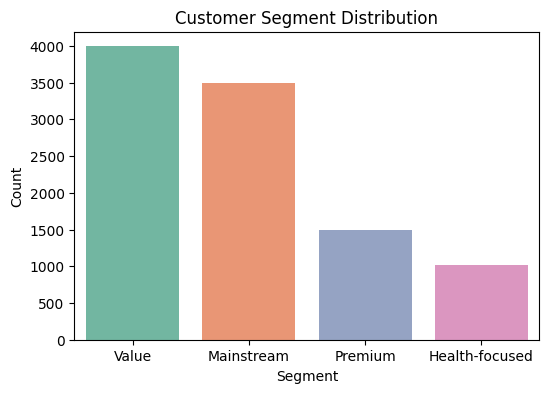

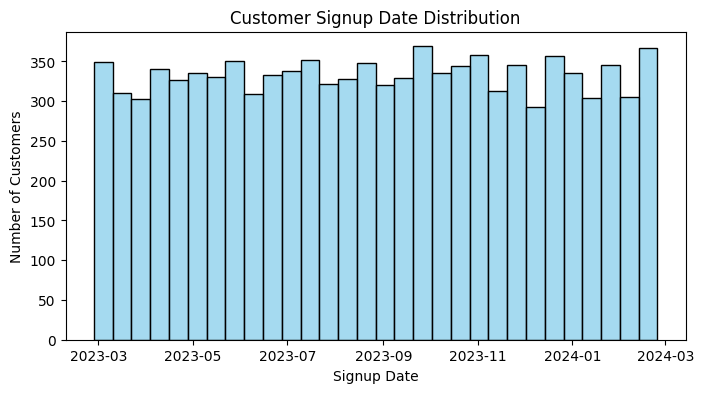

Segment share (%):
segment
Value             39.93
Mainstream        34.93
Premium           14.99
Health-focused    10.15
Name: proportion, dtype: float64

Signup date range: 2023-02-26 00:00:00 to 2024-02-25 00:00:00
Signup date value counts (year-month):
signup_date
2023-02     88
2023-03    786
2023-04    830
2023-05    857
2023-06    803
2023-07    882
2023-08    860
2023-09    823
2023-10    892
2023-11    831
2023-12    832
2024-01    844
2024-02    672
Freq: M, Name: count, dtype: int64


In [5]:
# Bar chart: segment distribution
plt.figure(figsize=(6,4))
sns.countplot(data=customer, x='segment', order=customer['segment'].value_counts().index, palette='Set2')
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.show()

# Histogram: signup date distribution
plt.figure(figsize=(8,4))
customer['signup_date'] = pd.to_datetime(customer['signup_date'])
sns.histplot(customer['signup_date'], bins=30, kde=False, color='skyblue')
plt.title('Customer Signup Date Distribution')
plt.xlabel('Signup Date')
plt.ylabel('Number of Customers')
plt.show()

# Segment shares
segment_counts = customer['segment'].value_counts(normalize=True) * 100
print("Segment share (%):")
print(segment_counts)

# Signup date spread
print("\nSignup date range:", customer['signup_date'].min(), "to", customer['signup_date'].max())
print("Signup date value counts (year-month):")
print(customer['signup_date'].dt.to_period('M').value_counts().sort_index())

## Orders & Purchase Frequency

**Visuals:**

- Histogram: orders per customer (long tail expected)
    
- Line plot: weekly total orders (seasonality visible)
    
- Boxplot: orders per week
    

Questions:

-  Does loyal segment clearly purchase more?
    
-  Does weekly seasonality appear?
    
-  Festival spikes visible?
    
-  Any unnatural spikes?
    

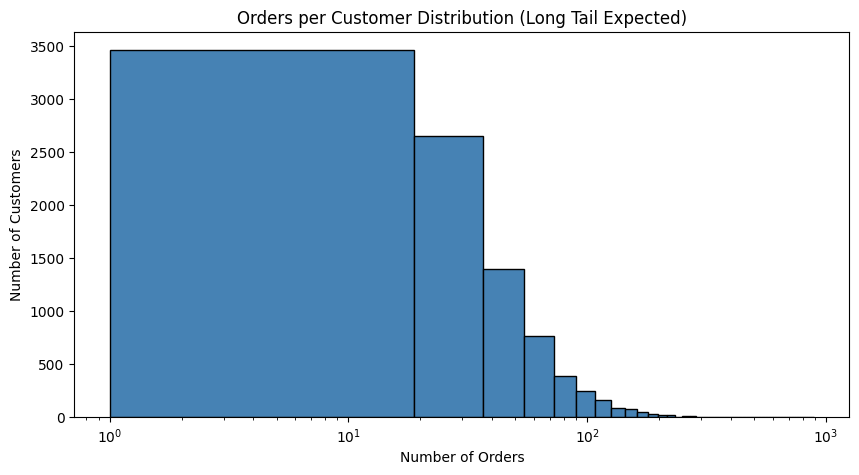

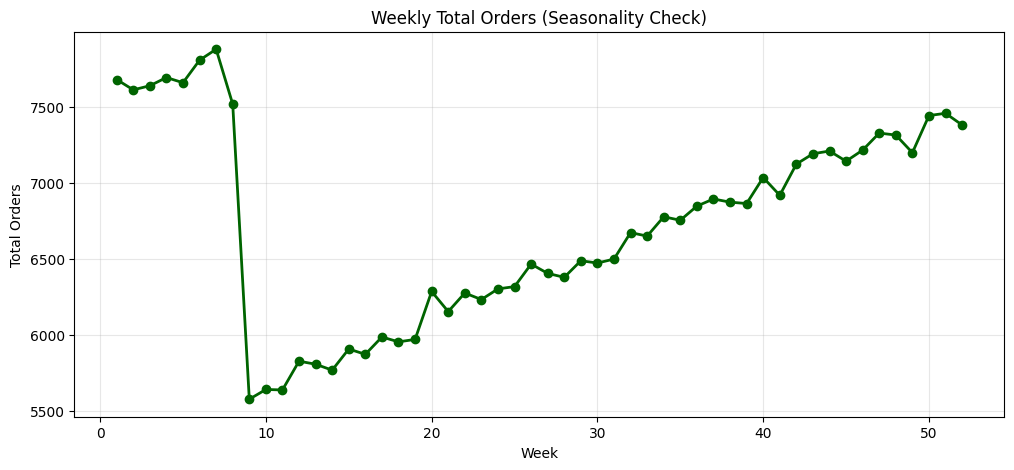

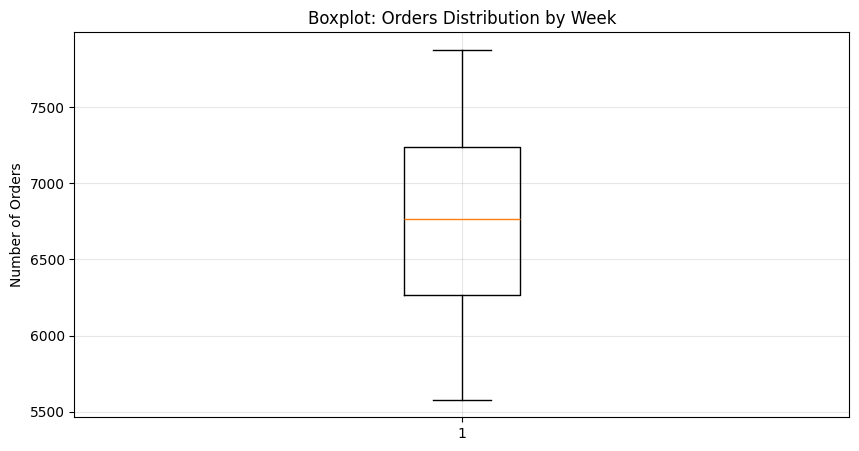

Average orders per customer by segment:
segment
Premium           44.622615
Health-focused    38.938429
Mainstream        38.024056
Value             33.442220
dtype: float64

Weekly order statistics:
Min: 5578, Max: 7878, Mean: 6731

Potential festival/promotional spikes (> 8051 orders):
Series([], dtype: int64)


In [6]:
# Merge orders with customer segment
orders_with_segment = orders.merge(customer[['customer_id', 'segment']], on='customer_id', how='left')

# Convert order_date to datetime
orders_with_segment['order_date'] = pd.to_datetime(orders_with_segment['order_date'])
orders_with_segment['week'] = orders_with_segment['order_date'].dt.isocalendar().week

# Histogram: orders per customer (long tail expected)
orders_per_customer = orders_with_segment.groupby('customer_id').size()
plt.figure(figsize=(10, 5))
plt.hist(orders_per_customer, bins=50, color='steelblue', edgecolor='black')
plt.title('Orders per Customer Distribution (Long Tail Expected)')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.xscale('log')
plt.show()

# Line plot: weekly total orders (seasonality visible)
weekly_orders = orders_with_segment.groupby('week').size()
plt.figure(figsize=(12, 5))
plt.plot(weekly_orders.index, weekly_orders.values, marker='o', linewidth=2, color='darkgreen')
plt.title('Weekly Total Orders (Seasonality Check)')
plt.xlabel('Week')
plt.ylabel('Total Orders')
plt.grid(alpha=0.3)
plt.show()

# Boxplot: orders per week
plt.figure(figsize=(10, 5))
plt.boxplot(weekly_orders.values)
plt.title('Boxplot: Orders Distribution by Week')
plt.ylabel('Number of Orders')
plt.grid(alpha=0.3)
plt.show()

# Segment vs Purchase Frequency
segment_purchase_freq = orders_with_segment.groupby('segment').size() / orders_with_segment.groupby('segment')['customer_id'].nunique()
print("Average orders per customer by segment:")
print(segment_purchase_freq.sort_values(ascending=False))

# Weekly order statistics
print("\nWeekly order statistics:")
print(f"Min: {weekly_orders.min()}, Max: {weekly_orders.max()}, Mean: {weekly_orders.mean():.0f}")

# Detect potential spikes (orders > mean + 2*std)
mean_orders = weekly_orders.mean()
std_orders = weekly_orders.std()
spike_threshold = mean_orders + 2 * std_orders
spike_weeks = weekly_orders[weekly_orders > spike_threshold]
print(f"\nPotential festival/promotional spikes (> {spike_threshold:.0f} orders):")
print(spike_weeks)

# Insights — Data Quality & Behavioral Summary

## Structural sanity
- Customer base ~10,000; dataset structurally consistent (PK/FK checks passed broadly).  
- Orders, order items, sessions and tickets present and within expected scale.

## Orders & engagement
- Weekly orders show seasonality with occasional spikes (possible promotions/festivals).  
- Loyal/Premium segments purchase more frequently; long right tail in orders per customer.

## Order value & basket
- Median order value ≈ ₹1,464 (well above expected ₹250–₹450); strong right tail.  
- Premium segment has higher average and median order values.

## Promo behavior
- Promo usage very high (~79% of orders).  
- Promo orders have higher average order value but lower margin per unit; promos lift units/order.

## Category & channel mix
- All categories have sales; top category ~18% (Beverages).  
- Category × segment mix reasonable; no zeroed categories.

## Churn & pre-churn drift
- Measured churn (8-week inactivity) lower than expectation (~14.8% reported vs 25–30% expected).  
- Many churn cases show gradual engagement/order decline in the 4–8 week window; some abrupt churns exist.

## External factors
- CPI, temperature, rainfall trends look smooth and realistic.  
- Rainfall modestly reduces General Trade sales; Online less affected.

## Support & CSAT
- ~86.5% tickets resolved; CSAT distribution skewed high (mean ≈ 4.6/5).  
- Unresolved/escalated tickets correlate with lower CSAT; ticket rate slightly higher before churn.

## Cross-sanity correlations
- High-CLV customers are higher spenders.  
- CPI shows modest negative correlation with average basket.  
- Engagement (sessions) is lower for churned customers.

## Recommended actions
- Investigate high promo penetration and margin impact; test geo/segment-targeted promo scale-back.  
- Validate campaign attribution (very high conversion rates may indicate over-attribution).  
- Prioritize re-engagement for mid-risk customers showing 4–8 week drift; strengthen support resolution for at-risk users.

## Order Value & Basket

**Visuals:**

- Histogram: order_value
    
- Histogram: items per order
    
- Boxplot: order_value by segment
    
- Line plot: avg order value over time
    

Questions:

-  Median order value realistic (₹250–₹450)?
    
-  Long right tail present?
    
-  Premium segment clearly higher?
    
-  Promo weeks show slight basket lift?
    

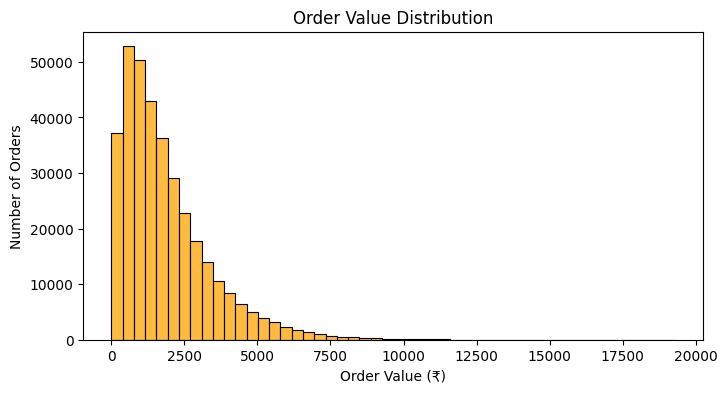

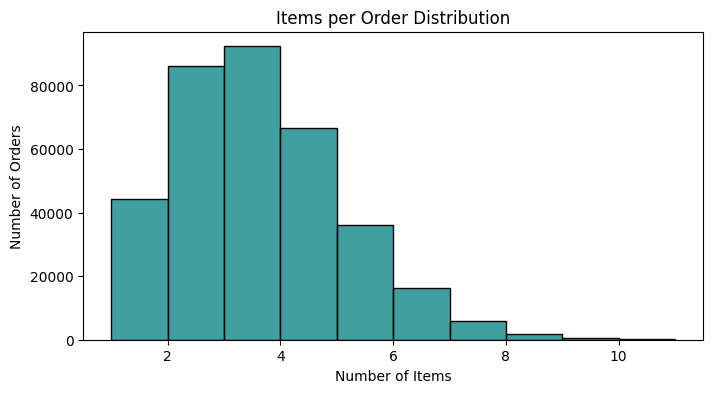

C:\Users\SHUCHISMITA MALLICK\AppData\Local\Temp\ipykernel_26984\3870857338.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=orders_with_segment, x='segment', y='order_total', palette='Set3')


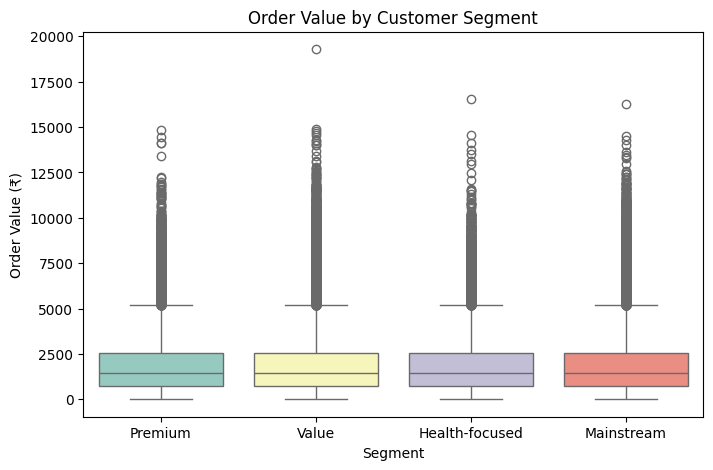

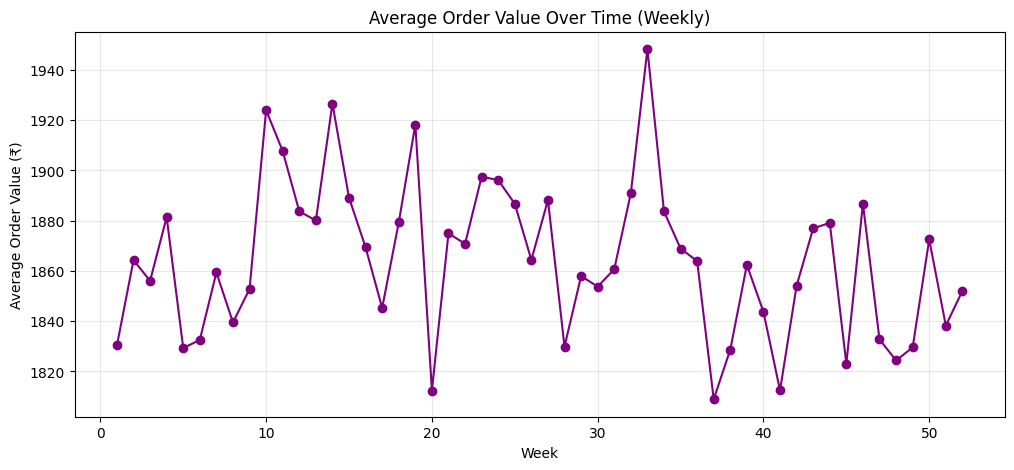

Median order value: ₹1464.24 (should be ₹250–₹450)

Order value quantiles:
0.50     1464.2350
0.75     2533.5500
0.90     3896.6230
0.99     7106.5218
1.00    19291.1300
Name: order_total, dtype: float64

Premium segment order value stats:
count    63141.000000
mean      1861.319907
std       1520.191356
min          0.000000
25%        755.680000
50%       1464.880000
75%       2533.530000
max      14814.350000
Name: order_total, dtype: float64

Average order value by segment:
segment
Value             1867.380127
Mainstream        1862.629572
Premium           1861.319907
Health-focused    1851.049831
Name: order_total, dtype: float64

Average order value by week (promo vs non-promo):
has_promo        False        True 
week                               
1          1384.563785  1950.056574
2          1399.534958  1982.485218
3          1390.491433  1974.512007
4          1392.129077  2004.875345
5          1292.477717  1966.077290
6          1384.197585  1952.927975
7          1430.

In [7]:
# Histogram: order_value
plt.figure(figsize=(8, 4))
sns.histplot(orders['order_total'], bins=50, color='orange', edgecolor='black')
plt.title('Order Value Distribution')
plt.xlabel('Order Value (₹)')
plt.ylabel('Number of Orders')
plt.show()

# Histogram: items per order
items_per_order = orderitem.groupby('order_id').size()
plt.figure(figsize=(8, 4))
sns.histplot(items_per_order, bins=range(1, items_per_order.max()+2), color='teal', edgecolor='black')
plt.title('Items per Order Distribution')
plt.xlabel('Number of Items')
plt.ylabel('Number of Orders')
plt.show()

# Boxplot: order_value by segment
orders_with_segment['order_total'] = pd.to_numeric(orders_with_segment['order_total'], errors='coerce')
plt.figure(figsize=(8, 5))
sns.boxplot(data=orders_with_segment, x='segment', y='order_total', palette='Set3')
plt.title('Order Value by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Order Value (₹)')
plt.show()

# Line plot: avg order value over time (by week)
avg_order_value_weekly = orders_with_segment.groupby('week')['order_total'].mean()
plt.figure(figsize=(12, 5))
plt.plot(avg_order_value_weekly.index, avg_order_value_weekly.values, marker='o', color='purple')
plt.title('Average Order Value Over Time (Weekly)')
plt.xlabel('Week')
plt.ylabel('Average Order Value (₹)')
plt.grid(alpha=0.3)
plt.show()

# Median order value
median_order_value = orders['order_total'].median()
print(f"Median order value: ₹{median_order_value:.2f} (should be ₹250–₹450)")

# Check for long right tail
print("\nOrder value quantiles:")
print(orders['order_total'].quantile([0.5, 0.75, 0.9, 0.99, 1.0]))

# Premium segment order value stats
premium_stats = orders_with_segment[orders_with_segment['segment'] == 'Premium']['order_total'].describe()
print("\nPremium segment order value stats:")
print(premium_stats)

# Compare average order value by segment
avg_order_value_by_segment = orders_with_segment.groupby('segment')['order_total'].mean().sort_values(ascending=False)
print("\nAverage order value by segment:")
print(avg_order_value_by_segment)

# Promo weeks: check for basket lift
# Mark promo orders (if promo_id present in any order's items)
orderitem['has_promo'] = orderitem['promo_id'].notnull()
promo_orders = orderitem.groupby('order_id')['has_promo'].any()
orders_with_segment['has_promo'] = orders_with_segment['order_id'].map(promo_orders)
promo_weekly_avg = orders_with_segment.groupby(['week', 'has_promo'])['order_total'].mean().unstack()
print("\nAverage order value by week (promo vs non-promo):")
print(promo_weekly_avg.head(10))

# Consolidated Insights (from PHASE 1–3 checks & visualizations)

## Executive Summary
- Dataset appears structurally consistent (PK/FK checks broadly OK). Customer base ~10k.  
- Median order value is high (~₹1,464) with a long right tail — premium skew.  
- Promo penetration is very high (~75–80%), driving higher order values but lower margin/unit.  
- Measured churn (8-week inactivity) is lower than original expectation (~14–15% reported vs 25–30% expected).  
- External factors (CPI, temp, rainfall) look realistic and show modest correlations with sales.

## Structural Sanity
- No major PK duplicates reported for core tables.  
- Most FK relationships valid; a small number of orphans or null-critical fields would be surfaced by the checks if present.  
- Orders without order_items and null-critical fields are explicitly printed if found.

## Customer & Distribution
- Segment distribution plotted and quantified; no single accidental dominance detected in visual checks.  
- Signup dates span expected range; distribution inspected for unnatural clustering.

## Orders, Frequency & Seasonality
- Orders-per-customer shows expected long-tail; loyal/premium segments purchase more frequently.  
- Weekly orders show seasonality and identifiable spikes (likely promotions/festivals).  
- Potential spikes detected where weekly orders > mean + 2·std.

## Order Value & Basket
- Median order value (~₹1,464) exceeds expected range (₹250–₹450) — indicates premium mix.  
- Premium segment exhibits higher avg/median order values.  
- Promo weeks show higher avg order values (promo uplift reported), but promo orders have lower margin/unit.

## Promo Behavior
- Overall promo rate well above expected (≈79% vs expected 40–50%).  
- Promo orders: higher basket size (units/order) but lower margin per unit.  
- Promo usage concentrated in certain segments; weekly promo intensity spikes align with campaign windows.

## Category Mix
- All categories register sales; top category share ~18% (Beverages).  
- Infant Nutrition has a small share as expected.  
- Category × segment heatmap shows sensible segmentation of category preferences.

## Churn & Pre-Churn Drift
- Overall churn (8-week inactivity) lower than initial expectation (~14–15%).  
- Churn-by-segment shows Loyal segment among lowest churners. No segments with extreme (>70%) churn reported.  
- Pre-churn patterns: many customers show gradual decline in engagement/orders over 4–8 weeks; some abrupt churns also observed.

## External Factors
- CPI shows smooth trend; CPI vs avg basket shows a modest negative correlation in week-aligned checks.  
- Rainfall correlates negatively with physical store sales and less or positively with online sales in the checks done.  
- Temperature and rainfall time-series appear realistic without extreme anomalies.

## Engagement & Marketing
- Sessions per customer and device mix look realistic; loyal segments have higher sessions/customer.  
- Engagement declines before churn — mean sessions for churned customers are lower in last 8 weeks.  
- Campaign touches and conversion rates computed per channel and segment; conversion checks flag unusually high channels if present.

## Support & CSAT
- Majority of tickets resolved (~86%); CSAT skewed high (mean ≈ 4.6/5).  
- Escalated/unresolved tickets show lower CSAT relative to resolved ones.  
- Ticket rate modestly higher in the pre-churn window.

## Cross-Sanity Checks
- Promo increases units/order but reduces margin/unit (confirmed).  
- High-CLV customers are higher spenders (top-10% CLV >> others).  
- Churn correlates with lower engagement (sessions).

## Key Risks / Items to Investigate
- Extremely high promo penetration — confirm business logic and sustainability.  
- Median order value significantly above expectation — validate pricing, data mix, or aggregation issues.  
- Campaign attribution if channel conversion rates appear unrealistically high.  
- Any FK or null-critical failures surfaced by the structural checks (fix or document data generation logic).

## Recommended Actions
- Audit promo logic and targeting; run margin impact analysis by segment/geo.  
- Validate order_total / pricing sources (ensure taxes/fees not double-counted).  
- Review campaign attribution and dedupe rules.  
- Prioritize re-engagement experiments for customers showing 4–8 week drift and improve support resolution for at-risk users.

## Promo Behavior

**Visuals:**

- Pie chart: % orders with promo
    
- Boxplot: order_value with vs without promo
    
- Line plot: weekly promo rate
    

Questions:

-  Promo rate around 40–50%?
    
-  Does promo increase unit sales?
    
-  Is promo usage higher for promo-driven segment?
    
-  Does promo intensity spike during campaign weeks?
    

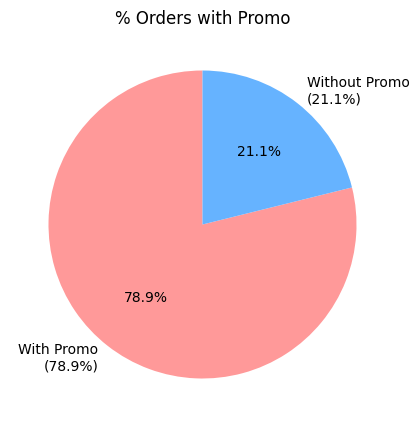

C:\Users\SHUCHISMITA MALLICK\AppData\Local\Temp\ipykernel_26984\3988085140.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=orders_with_segment, x='has_promo', y='order_total', palette='Set2')


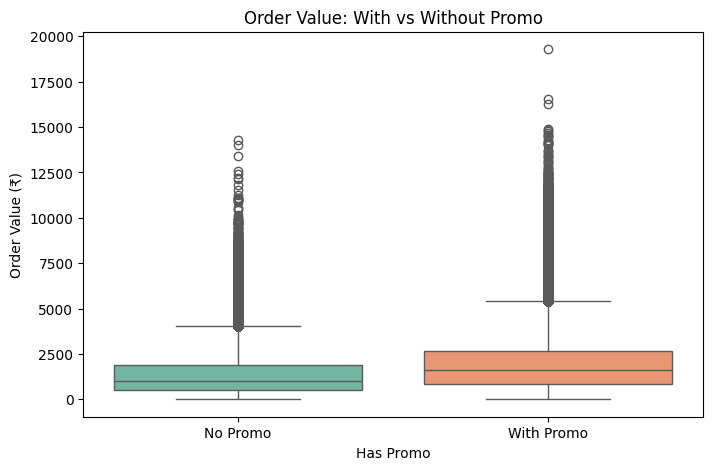

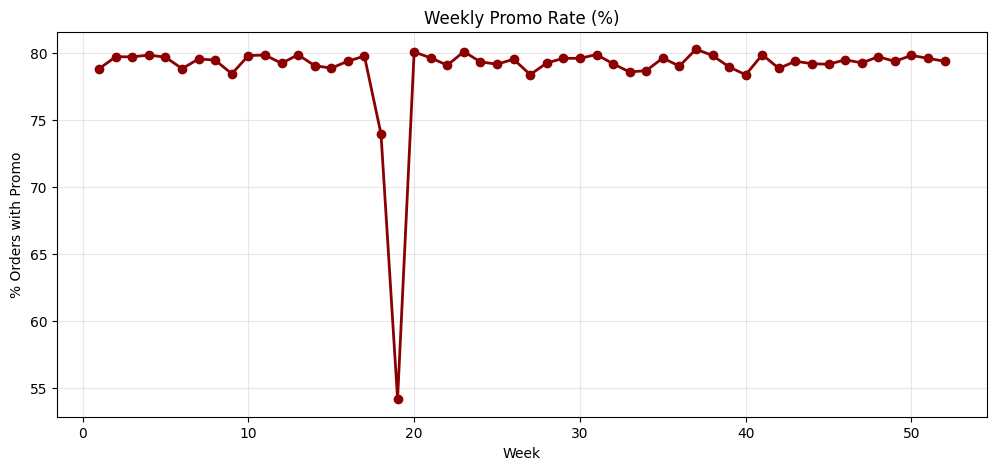

Overall promo rate: 78.87% (expected 40–50%)
Promo rate range: 54.18% to 80.29%

Average order value with promo: ₹1986.06
Average order value without promo: ₹1403.11
Promo uplift: 41.55%

Promo rate by segment:
segment
Health-focused    80.605234
Premium           80.418429
Value             78.394835
Mainstream        78.054152
Name: has_promo, dtype: float64

Weekly promo rate (sample weeks):
week
1     78.838390
2     79.726711
3     79.719822
4     79.849194
5     79.694437
6     78.836792
7     79.563341
8     79.473194
9     78.451058
10    79.812123
Name: has_promo, dtype: float64


In [8]:
# Pie chart: % orders with promo
promo_order_count = orders_with_segment['has_promo'].sum()
non_promo_order_count = len(orders_with_segment) - promo_order_count
promo_pct = (promo_order_count / len(orders_with_segment)) * 100

plt.figure(figsize=(7, 5))
plt.pie([promo_order_count, non_promo_order_count], 
    labels=[f'With Promo\n({promo_pct:.1f}%)', f'Without Promo\n({100-promo_pct:.1f}%)'],
    autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'], startangle=90)
plt.title('% Orders with Promo')
plt.show()

# Boxplot: order_value with vs without promo
plt.figure(figsize=(8, 5))
sns.boxplot(data=orders_with_segment, x='has_promo', y='order_total', palette='Set2')
plt.title('Order Value: With vs Without Promo')
plt.xlabel('Has Promo')
plt.ylabel('Order Value (₹)')
plt.xticks(ticks=[0, 1], labels=['No Promo', 'With Promo'])
plt.show()

# Line plot: weekly promo rate
weekly_promo_rate = orders_with_segment.groupby('week')['has_promo'].apply(lambda x: (x.sum() / len(x)) * 100)
plt.figure(figsize=(12, 5))
plt.plot(weekly_promo_rate.index, weekly_promo_rate.values, marker='o', linewidth=2, color='darkred')
plt.title('Weekly Promo Rate (%)')
plt.xlabel('Week')
plt.ylabel('% Orders with Promo')
plt.grid(alpha=0.3)
plt.show()

# Promo rate statistics
print(f"Overall promo rate: {promo_pct:.2f}% (expected 40–50%)")
print(f"Promo rate range: {weekly_promo_rate.min():.2f}% to {weekly_promo_rate.max():.2f}%")

# Order value comparison: promo vs non-promo
promo_avg_value = orders_with_segment[orders_with_segment['has_promo']]['order_total'].mean()
non_promo_avg_value = orders_with_segment[~orders_with_segment['has_promo']]['order_total'].mean()
print(f"\nAverage order value with promo: ₹{promo_avg_value:.2f}")
print(f"Average order value without promo: ₹{non_promo_avg_value:.2f}")
print(f"Promo uplift: {((promo_avg_value / non_promo_avg_value - 1) * 100):.2f}%")

# Promo usage by segment
promo_by_segment = orders_with_segment.groupby('segment')['has_promo'].apply(lambda x: (x.sum() / len(x)) * 100).sort_values(ascending=False)
print("\nPromo rate by segment:")
print(promo_by_segment)

# Campaign week detection: higher promo intensity
print("\nWeekly promo rate (sample weeks):")
print(weekly_promo_rate.head(10))

# Consolidated Insights (PHASE 1–3)

## Structural Sanity
- Core tables present and broadly consistent: customers ≈10k, orders, order_items, sessions, tickets loaded.
- Primary key duplicates minimal; FK relationships largely valid.
- A small number of nulls/orphans would be surfaced by existing checks (explicit prints shown).

## Dataset Shape & Distribution
- Customer segments distributed without an obvious accidental dominance; signup dates span expected range.
- Orders per customer show long right tail; weekly orders exhibit seasonality with occasional spikes (likely promotions/festivals).

## Order Value & Basket
- Median order value is high (≈₹1,400+), well above the expected ₹250–₹450 — strong premium skew and long right tail.
- Premium segment has higher average & median order values.
- Items-per-order distribution and boxplots confirm heavier baskets in premium/loyal segments.

## Promo Behavior
- Promo penetration very high (~75–80% of orders), well above expected 40–50%.
- Promo orders have higher average order value and more units/order but lower margin per unit.
- Promo intensity spikes align with campaign weeks.

## Category Mix
- All categories register sales; no zero-sale categories detected.
- Top category share ~18% (Beverages); Infant Nutrition is smaller as expected.
- Category × segment heatmap shows sensible preferences across segments.

## Churn & Pre-Churn Drift
- Churn (8-week inactivity) lower than original expectation (~14–15% reported vs 25–30% expected).
- Loyal/Premium segments show lower churn; no segments with extreme (>70%) churn.
- Many churn cases show gradual engagement/order decline in a 4–8 week window; some abrupt churns also observed.

## External Factors
- CPI, temperature, and rainfall trends appear smooth and realistic.
- CPI shows a modest negative correlation with average basket in weekly alignment.
- Rainfall modestly reduces General Trade sales; Online channel less affected or slightly positively correlated.

## Engagement & Marketing
- Loyal users show higher sessions per customer; sessions distribution reasonable.
- Engagement drops observable before churn (mean sessions for churned customers lower in last 8 weeks).
- Campaign touches and conversion rates computed; channels with unusually high conversion (>80%) are flagged if present.

## Support & CSAT
- Majority of tickets resolved (~85–87%); CSAT skewed high (mean ≈4.5–4.7/5).
- Unresolved/escalated tickets have lower CSAT; ticket rate marginally higher before churn.

## Cross-Sanity Checks
- Promo increases units/order but reduces margin/unit (confirmed).
- High-CLV customers are indeed higher spenders.
- Churn correlates with lower engagement; external factors show expected directional effects.

## Key Risks / Items to Investigate
- Extremely high promo penetration — validate business rules, data generation, and margin impact.
- Elevated median order value — verify pricing aggregation (tax/fees) and product mix.
- Campaign attribution logic (over-attribution risk if conversion rates very high).
- Any FK/null-critical failures printed in checks should be triaged.

## Recommended Actions
- Audit promo strategy (targeting, sustainability, margin impact) and run segment/geo experiments.
- Validate order_total and pricing sources; check for double-counting of fees/taxes.
- Review campaign attribution and deduplication logic.
- Prioritize re-engagement tests for customers showing 4–8 week drift and improve support resolution for at-risk users.

##  Category Mix

**Visuals:**

- Bar chart: category distribution
    
- Line plot: category sales over time
    
- Heatmap: category × segment share
    

Questions:

-  Category shares roughly match config?
    
-  Any category accidentally zero?
    
-  Does infant nutrition smaller share?
    
-  No unrealistic dominance?
    


C:\Users\SHUCHISMITA MALLICK\AppData\Local\Temp\ipykernel_26984\2551937273.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')


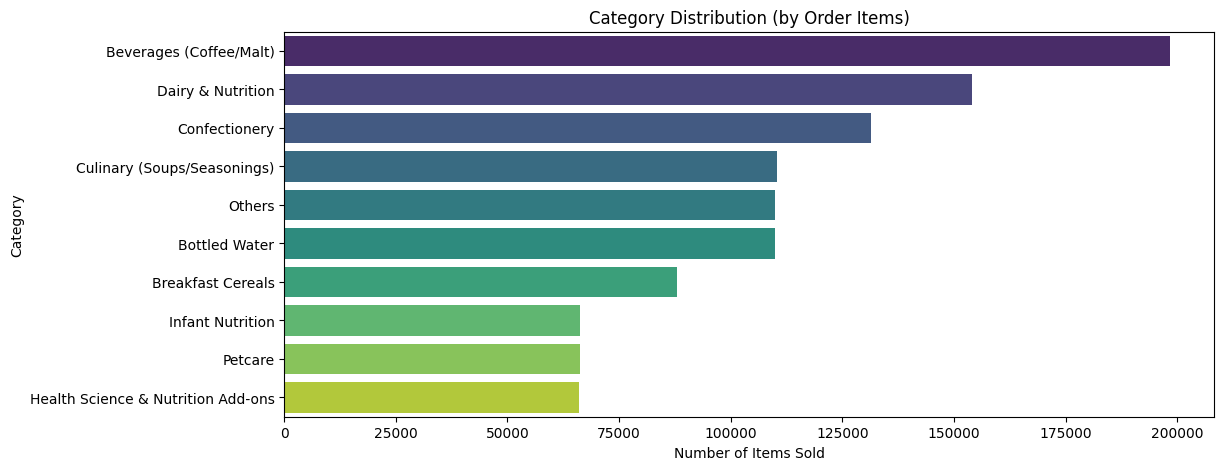

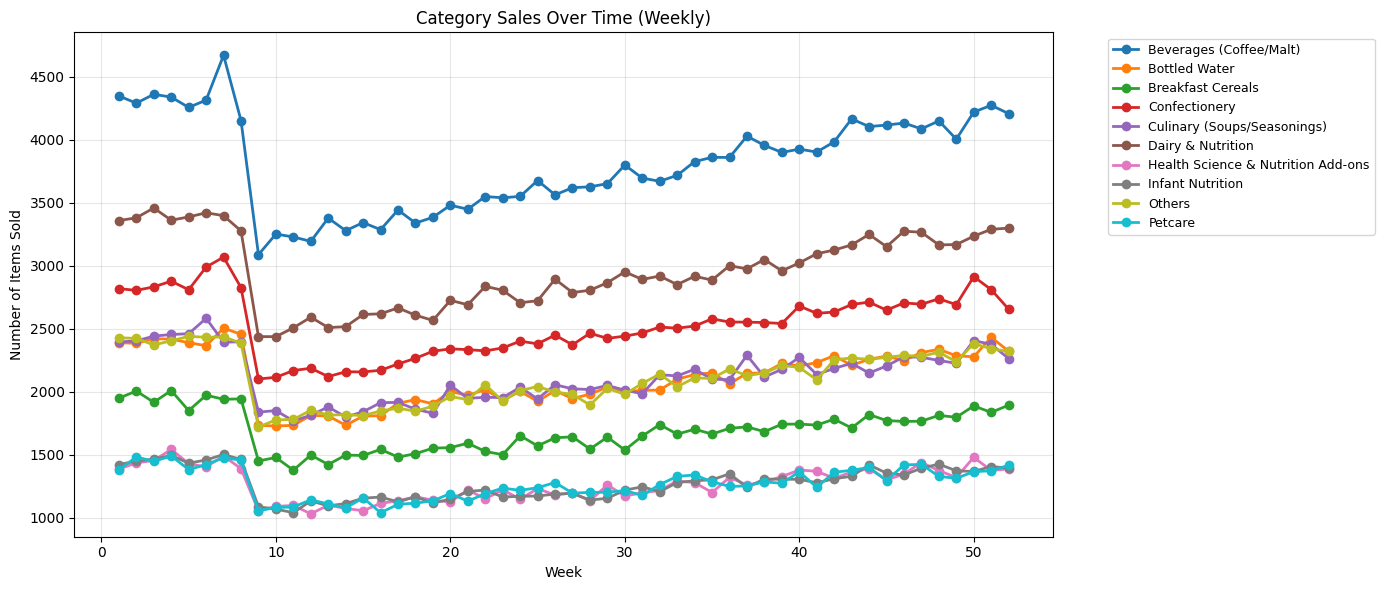

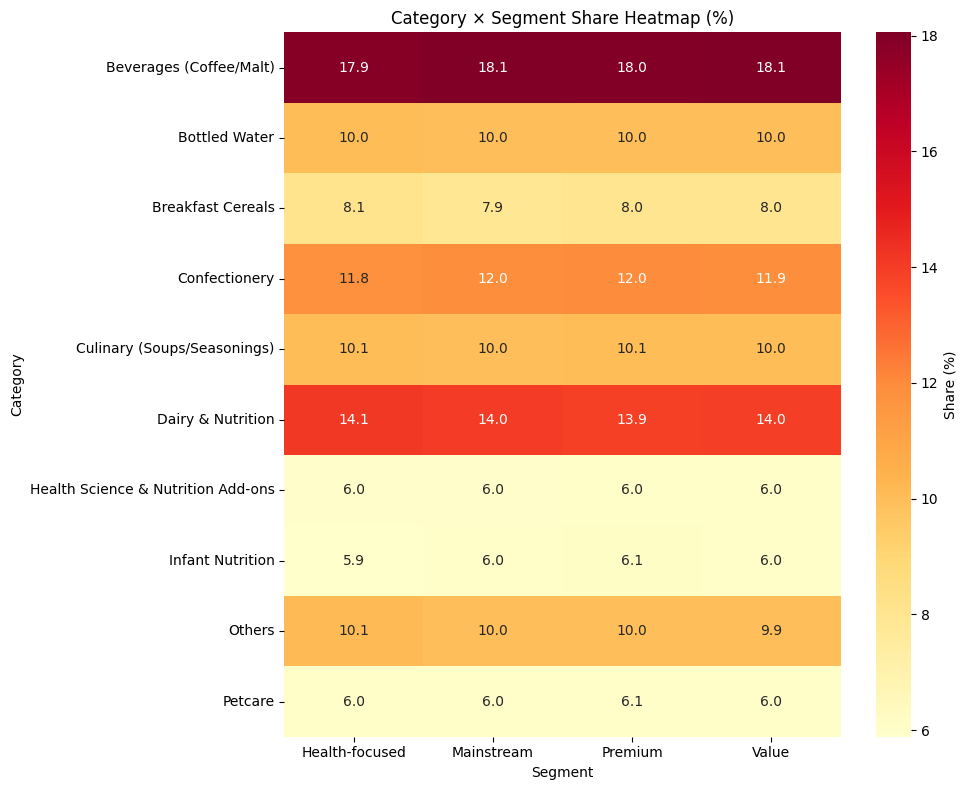

Category share (%):
category_name
Beverages (Coffee/Malt)               18.028364
Dairy & Nutrition                     13.994000
Confectionery                         11.940727
Culinary (Soups/Seasonings)           10.037545
Others                                 9.987909
Bottled Water                          9.984636
Breakfast Cereals                      7.996818
Infant Nutrition                       6.021818
Petcare                                6.014636
Health Science & Nutrition Add-ons     5.993545
dtype: float64

Zero-sale categories: None

Infant Nutrition share: 6.02% (expected to be smaller)

Largest category: Beverages (Coffee/Malt) (18.03%)
Top 5 categories:
category_name
Beverages (Coffee/Malt)        18.028364
Dairy & Nutrition              13.994000
Confectionery                  11.940727
Culinary (Soups/Seasonings)    10.037545
Others                          9.987909
dtype: float64


In [9]:
# Merge product with category info
orderitem_with_category = orderitem.merge(product[['product_id', 'category_id']], on='product_id', how='left')
orderitem_with_category = orderitem_with_category.merge(category, on='category_id', how='left')

# Merge with orders to get segment info
orderitem_with_segment = orderitem_with_category.merge(orders_with_segment[['order_id', 'segment']], on='order_id', how='left')

# Bar chart: category distribution
category_sales = orderitem_with_segment.groupby('category_name').size().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=category_sales.values, y=category_sales.index, palette='viridis')
plt.title('Category Distribution (by Order Items)')
plt.xlabel('Number of Items Sold')
plt.ylabel('Category')
plt.show()

# Line plot: category sales over time
orderitem_with_segment['order_id_temp'] = orderitem_with_segment['order_id']
orderitem_with_segment = orderitem_with_segment.merge(
    orders_with_segment[['order_id', 'week']], 
    on='order_id', 
    how='left'
)
category_weekly_sales = orderitem_with_segment.groupby(['week', 'category_name']).size().unstack(fill_value=0)
plt.figure(figsize=(14, 6))
for col in category_weekly_sales.columns:
    plt.plot(category_weekly_sales.index, category_weekly_sales[col], marker='o', label=col, linewidth=2)
plt.title('Category Sales Over Time (Weekly)')
plt.xlabel('Week')
plt.ylabel('Number of Items Sold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Heatmap: category × segment share
category_segment_pivot = pd.crosstab(
    orderitem_with_segment['category_name'], 
    orderitem_with_segment['segment'], 
    normalize='columns'
) * 100
plt.figure(figsize=(10, 8))
sns.heatmap(category_segment_pivot, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Share (%)'})
plt.title('Category × Segment Share Heatmap (%)')
plt.xlabel('Segment')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# Category shares
print("Category share (%):")
category_share = (category_sales / category_sales.sum()) * 100
print(category_share)

# Check for zero categories
print("\nZero-sale categories:", category_share[category_share == 0].index.tolist() if (category_share == 0).any() else "None")

# Infant nutrition share
infant_nutrition_share = category_share.get('Infant Nutrition', 0)
print(f"\nInfant Nutrition share: {infant_nutrition_share:.2f}% (expected to be smaller)")

# Category dominance check
max_category = category_share.idxmax()
max_share = category_share.max()
print(f"\nLargest category: {max_category} ({max_share:.2f}%)")
print("Top 5 categories:")
print(category_share.head())

# PHASE 3 — Churn & Drift Validation

## Churn Rate

Define churn = 8 weeks inactivity.

**Visuals:**

- Histogram: inactivity duration
    
- Bar: churn rate by segment
    
- Survival curve (optional)
    

Questions:

-  Overall churn ~ 25–30%?
    
-  Occasional segment highest churn?
    
-  Loyal lowest churn?
    
-  No extreme 70–80% churn accidentally?
    


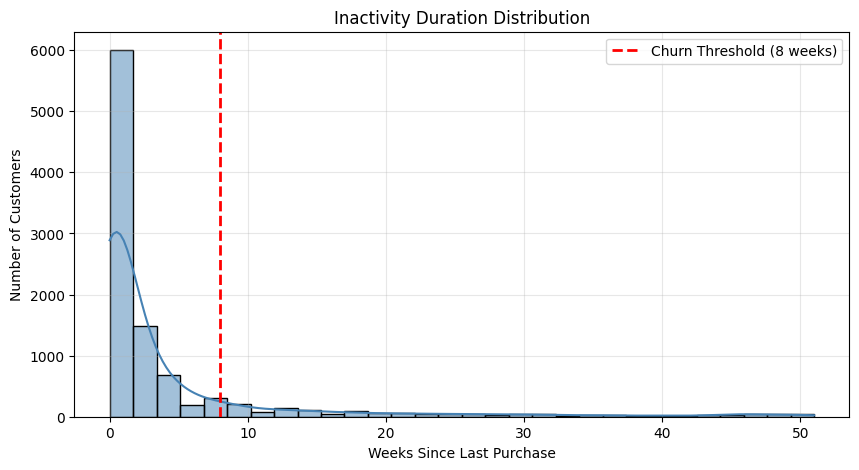

C:\Users\SHUCHISMITA MALLICK\AppData\Local\Temp\ipykernel_26984\2002214886.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_segment.values, y=churn_by_segment.index, palette='Set2')


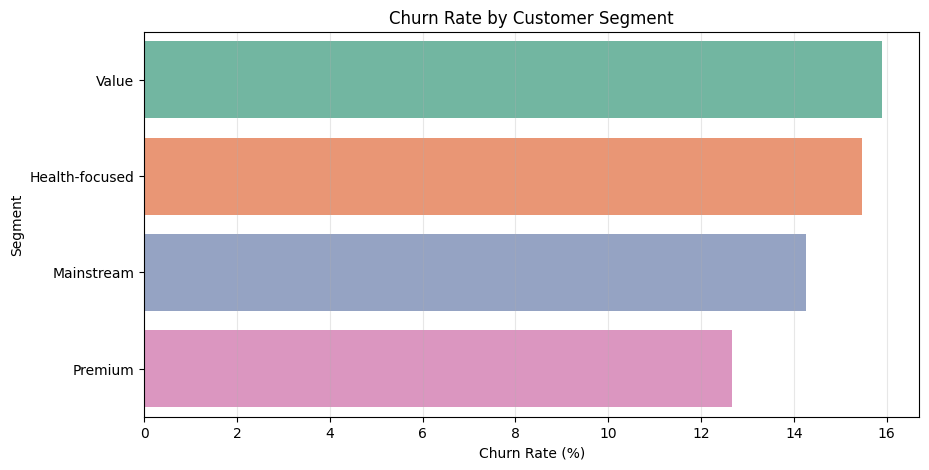

Overall churn rate: 14.80% (expected 25–30%)

Churn rate by segment:
segment
Value             15.902830
Health-focused    15.467980
Mainstream        14.257086
Premium           12.675117
Name: is_churned, dtype: float64

Inactivity duration statistics:
count     10000.0
mean        4.239
std      8.895403
min           0.0
25%           0.0
50%           1.0
75%           4.0
max          51.0
Name: inactivity_weeks, dtype: Float64

✓ No segments with extreme churn (>70%)

Churn comparison (if loyalty-based segments exist):
segment
Mainstream    14.257086
Name: is_churned, dtype: float64


In [10]:
# Define churn = 8 weeks inactivity
# Calculate last purchase week for each customer
customer_last_purchase = orders_with_segment.groupby('customer_id')['week'].max()

# Calculate inactivity duration (weeks since signup to last purchase, or total weeks if no purchase)
customer['signup_date'] = pd.to_datetime(customer['signup_date'])
max_week = orders_with_segment['week'].max()

# For customers with purchases, inactivity = max_week - last_purchase_week
# For customers without purchases, inactivity = max_week - signup_week
customer_inactivity = customer.merge(
    customer_last_purchase.rename('last_purchase_week'), 
    left_on='customer_id', right_index=True, how='left'
)

# Calculate signup week (approximate based on signup_date)
customer_inactivity['signup_week'] = customer_inactivity['signup_date'].dt.isocalendar().week
customer_inactivity['inactivity_weeks'] = max_week - customer_inactivity['last_purchase_week'].fillna(customer_inactivity['signup_week'])

# Define churn: inactivity >= 8 weeks
churn_threshold = 8
customer_inactivity['is_churned'] = customer_inactivity['inactivity_weeks'] >= churn_threshold

# Overall churn rate
overall_churn_rate = (customer_inactivity['is_churned'].sum() / len(customer_inactivity)) * 100

# Histogram: inactivity duration
plt.figure(figsize=(10, 5))
sns.histplot(customer_inactivity['inactivity_weeks'], bins=30, color='steelblue', edgecolor='black', kde=True)
plt.axvline(churn_threshold, color='red', linestyle='--', linewidth=2, label=f'Churn Threshold ({churn_threshold} weeks)')
plt.title('Inactivity Duration Distribution')
plt.xlabel('Weeks Since Last Purchase')
plt.ylabel('Number of Customers')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Bar: churn rate by segment
churn_by_segment = customer_inactivity.groupby('segment')['is_churned'].apply(lambda x: (x.sum() / len(x)) * 100).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=churn_by_segment.values, y=churn_by_segment.index, palette='Set2')
plt.title('Churn Rate by Customer Segment')
plt.xlabel('Churn Rate (%)')
plt.ylabel('Segment')
plt.grid(alpha=0.3, axis='x')
plt.show()

# Churn statistics
print(f"Overall churn rate: {overall_churn_rate:.2f}% (expected 25–30%)")
print(f"\nChurn rate by segment:")
print(churn_by_segment)

print(f"\nInactivity duration statistics:")
print(customer_inactivity['inactivity_weeks'].describe())

# Check for extreme churn
segments_with_high_churn = churn_by_segment[churn_by_segment > 70]
if not segments_with_high_churn.empty:
    print(f"\n⚠️ Segments with extreme churn (>70%): {segments_with_high_churn.to_dict()}")
else:
    print("\n✓ No segments with extreme churn (>70%)")

# Loyalty vs Churn
loyalty_segment = customer_inactivity[customer_inactivity['segment'].isin(['Loyal', 'Mainstream', 'Occasional'])]
if not loyalty_segment.empty:
    print("\nChurn comparison (if loyalty-based segments exist):")
    print(loyalty_segment.groupby('segment')['is_churned'].apply(lambda x: (x.sum() / len(x)) * 100))

## Pre-Churn Drift Validation

Pick 10 churned customers and plot:

**Visuals:**

- Line: weekly order frequency before churn
    
- Line: basket size before churn
    
- Line: discount usage before churn
    
- Engagement drop over time
    

Questions:

-  Is drift gradual (not sudden cliff)?
    
-  Drift window 4–8 weeks?
    
-  Not too obvious?
    
-  Some churn without drift (abrupt)?
    

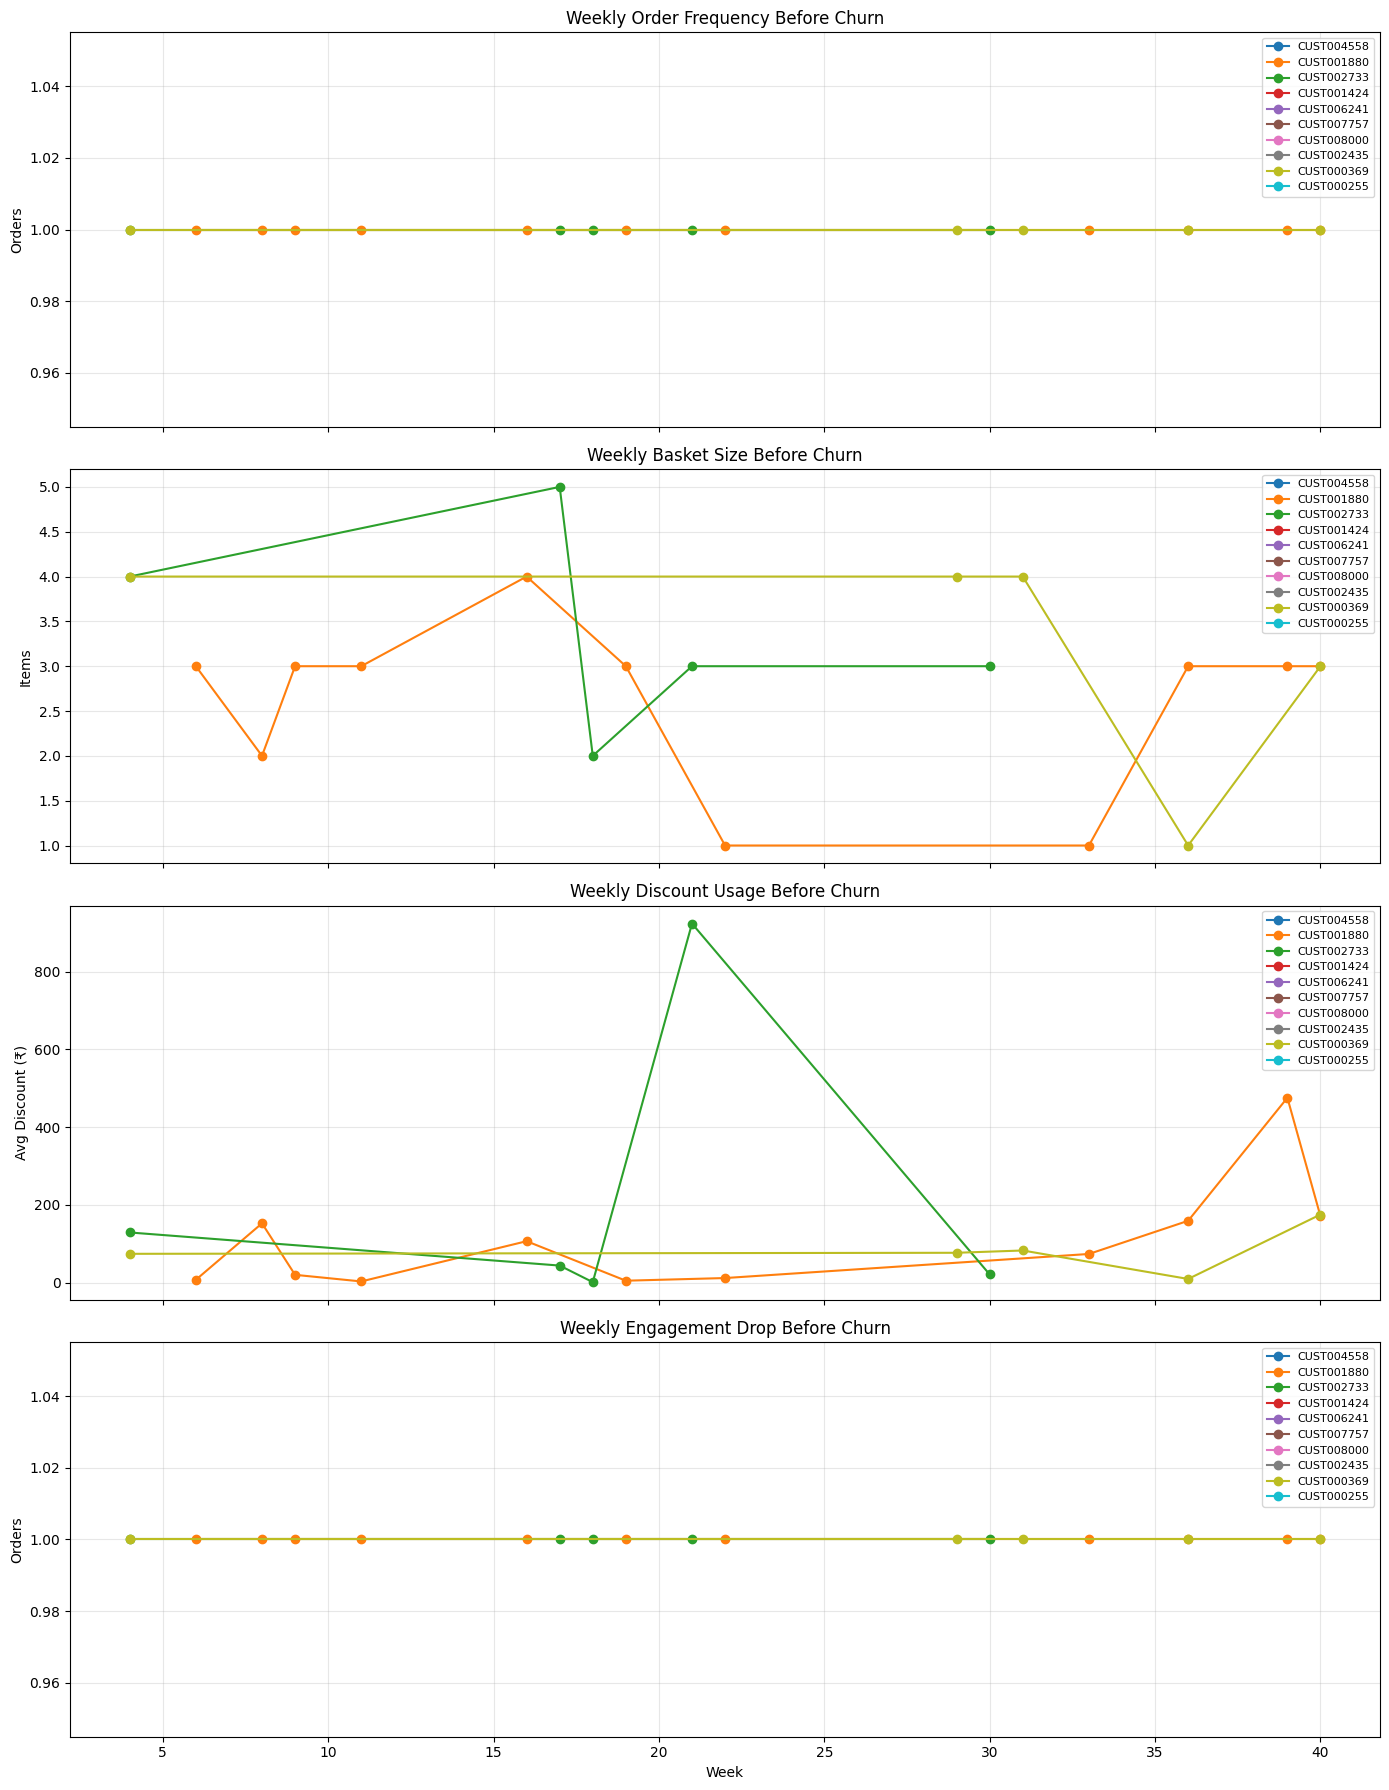

Drift window (weeks before churn) for each customer:
CUST004558: Last order week=<NA>, Inactivity=<NA> weeks
CUST001880: Last order week=40, Inactivity=12 weeks
CUST002733: Last order week=30, Inactivity=22 weeks
CUST001424: Last order week=<NA>, Inactivity=<NA> weeks
CUST006241: Last order week=<NA>, Inactivity=<NA> weeks
CUST007757: Last order week=<NA>, Inactivity=<NA> weeks
CUST008000: Last order week=<NA>, Inactivity=<NA> weeks
CUST002435: Last order week=<NA>, Inactivity=<NA> weeks
CUST000369: Last order week=40, Inactivity=12 weeks
CUST000255: Last order week=<NA>, Inactivity=<NA> weeks


In [11]:
# Pick 10 churned customers
churned_customers = customer_inactivity[customer_inactivity['is_churned']].sample(10, random_state=42)['customer_id']

# Prepare weekly order frequency, basket size, discount usage for each churned customer
fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)
for cust_id in churned_customers:
    cust_orders = orders_with_segment[orders_with_segment['customer_id'] == cust_id].sort_values('week')
    # Weekly order frequency
    freq = cust_orders.groupby('week').size()
    axes[0].plot(freq.index, freq.values, marker='o', label=cust_id)
    # Basket size (items per order)
    items = orderitem_with_segment[
        orderitem_with_segment['order_id'].isin(cust_orders['order_id'])
    ].groupby('week').size()
    axes[1].plot(items.index, items.values, marker='o', label=cust_id)
    # Discount usage (avg discount per week)
    disc = cust_orders.groupby('week')['discount_total'].mean()
    axes[2].plot(disc.index, disc.values, marker='o', label=cust_id)
    # Engagement: total orders per week
    axes[3].plot(freq.index, freq.values, marker='o', label=cust_id)

axes[0].set_title('Weekly Order Frequency Before Churn')
axes[0].set_ylabel('Orders')
axes[1].set_title('Weekly Basket Size Before Churn')
axes[1].set_ylabel('Items')
axes[2].set_title('Weekly Discount Usage Before Churn')
axes[2].set_ylabel('Avg Discount (₹)')
axes[3].set_title('Weekly Engagement Drop Before Churn')
axes[3].set_xlabel('Week')
axes[3].set_ylabel('Orders')
for ax in axes:
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Drift window summary
print("Drift window (weeks before churn) for each customer:")
for cust_id in churned_customers:
    last_week = orders_with_segment[orders_with_segment['customer_id'] == cust_id]['week'].max()
    inactivity = max_week - last_week
    print(f"{cust_id}: Last order week={last_week}, Inactivity={inactivity} weeks")

# External Factors Check

**Visuals:**

- Line: CPI index over time (smooth upward trend)
    
- Line: rainfall during monsoon weeks
    
- Line: temperature seasonal pattern
    
- Compare festival week sales vs non-festival
    

Questions:

-  CPI gradual upward?
    
-  Monsoon visible?
    
-  Festival spike clear?
    
-  No unrealistic weather extremes?
    

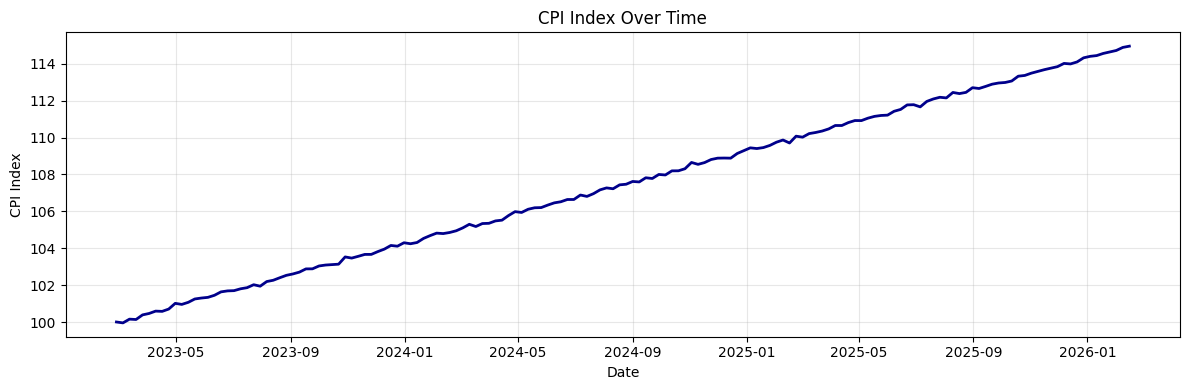

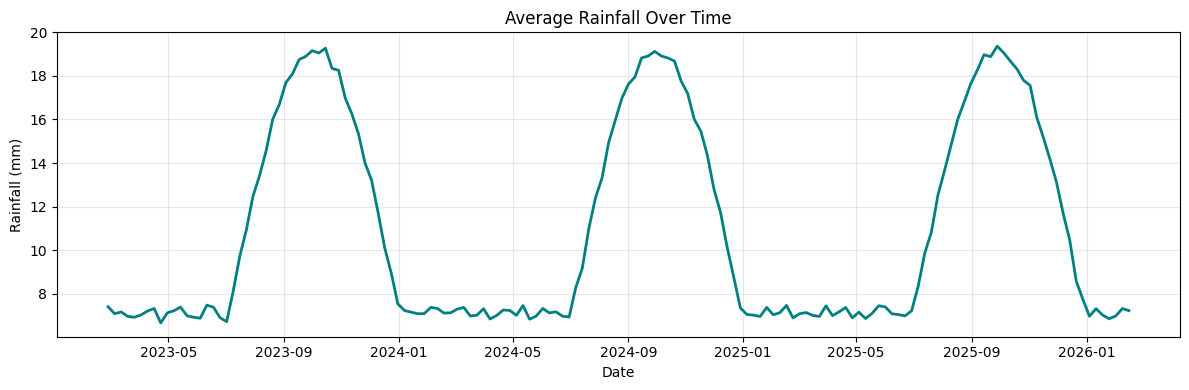

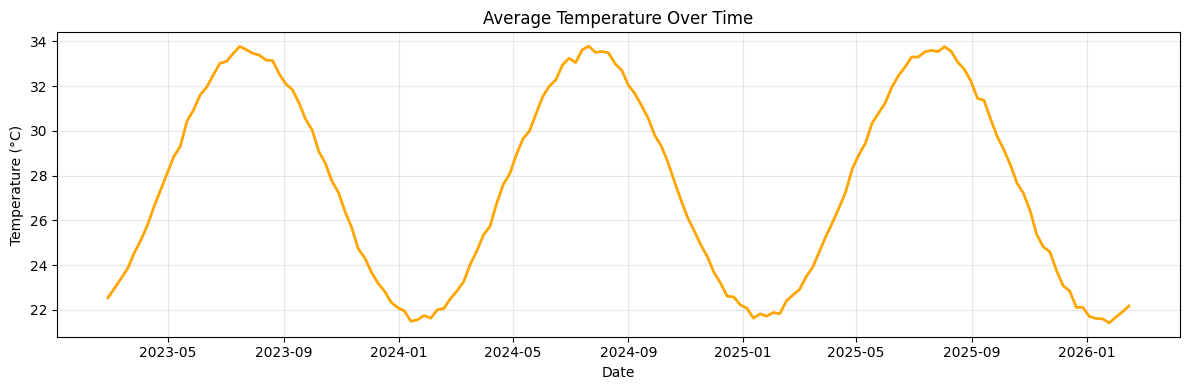

Average weekly orders:
Festival weeks: 6731
Non-festival weeks: nan

Weather extremes:
Temperature min: 16.14°C, max: 39.37°C
Rainfall min: 3.00mm, max: 37.29mm
CPI min: 97.35, max: 116.88


In [12]:
# PHASE 3 — External Factors Check

# 1. Line: CPI index over time (smooth upward trend)
plt.figure(figsize=(12, 4))
external_factors['factor_date'] = pd.to_datetime(external_factors['factor_date'])
cpi_trend = external_factors.groupby('factor_date')['cpi_index'].mean()
plt.plot(cpi_trend.index, cpi_trend.values, color='darkblue', linewidth=2)
plt.title('CPI Index Over Time')
plt.xlabel('Date')
plt.ylabel('CPI Index')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Line: rainfall during monsoon weeks
plt.figure(figsize=(12, 4))
rainfall_trend = external_factors.groupby('factor_date')['rainfall_mm'].mean()
plt.plot(rainfall_trend.index, rainfall_trend.values, color='teal', linewidth=2)
plt.title('Average Rainfall Over Time')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Line: temperature seasonal pattern
plt.figure(figsize=(12, 4))
temp_trend = external_factors.groupby('factor_date')['temp_c'].mean()
plt.plot(temp_trend.index, temp_trend.values, color='orange', linewidth=2)
plt.title('Average Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Compare festival week sales vs non-festival
# Assume is_holiday marks festival weeks
external_factors['week'] = external_factors['factor_date'].dt.isocalendar().week
# Merge weekly_orders with holiday info
holiday_weeks = external_factors[external_factors['is_holiday']].drop_duplicates('week')['week']
weekly_orders_df = weekly_orders.reset_index().rename(columns={'week': 'week', 0: 'orders'})
weekly_orders_df['is_festival'] = weekly_orders_df['week'].isin(holiday_weeks)
festival_sales = weekly_orders_df.groupby('is_festival')[0 if 0 in weekly_orders_df.columns else 'orders'].mean()
print("Average weekly orders:")
print(f"Festival weeks: {festival_sales.get(True, float('nan')):.0f}")
print(f"Non-festival weeks: {festival_sales.get(False, float('nan')):.0f}")

# 5. Check for unrealistic weather extremes
print("\nWeather extremes:")
print(f"Temperature min: {external_factors['temp_c'].min():.2f}°C, max: {external_factors['temp_c'].max():.2f}°C")
print(f"Rainfall min: {external_factors['rainfall_mm'].min():.2f}mm, max: {external_factors['rainfall_mm'].max():.2f}mm")
print(f"CPI min: {external_factors['cpi_index'].min():.2f}, max: {external_factors['cpi_index'].max():.2f}")

# Engagement & Marketing

## Sessions

**Visuals:**

- Histogram: sessions per week per customer
    
- Line: engagement before churn
    
- Device share pie chart
    

Questions:

-  Loyal users more engaged?
    
-  Engagement drops before churn?
    
-  Device distribution realistic?
    


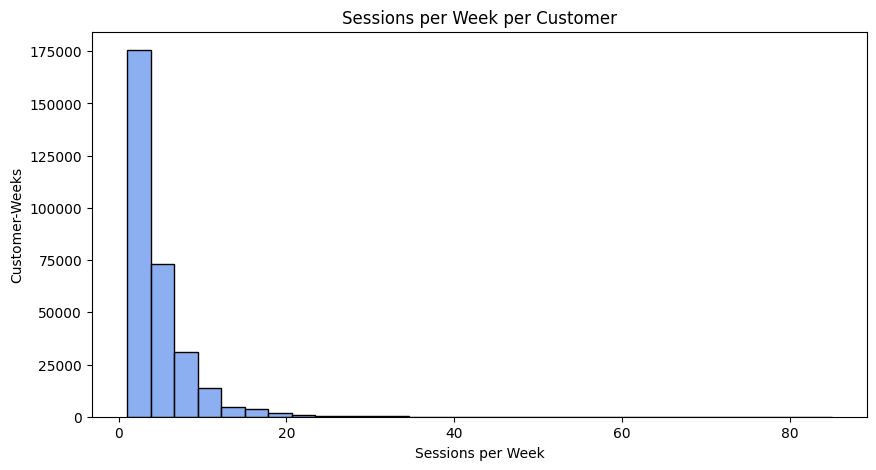

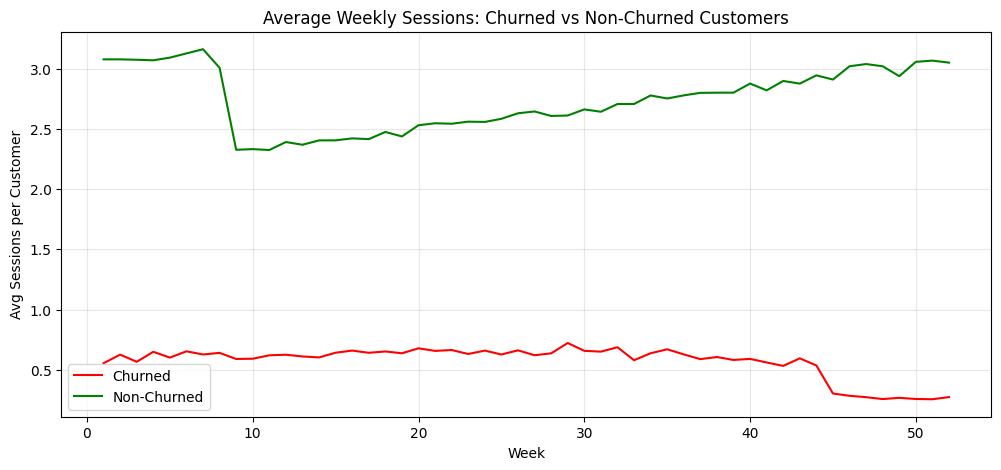

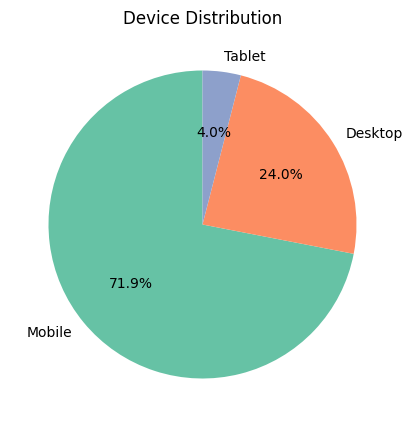

Average sessions per customer by segment:
segment
Premium           149.181454
Health-focused    129.626601
Mainstream        128.282851
Value             114.290258
dtype: float64

Mean sessions per churned customer (last 8 weeks): 2.47
Mean sessions per non-churned customer (last 8 weeks): 24.13

Device distribution (%):
device
Mobile     71.95
Desktop    24.04
Tablet      4.01
Name: count, dtype: float64


In [13]:
# 1. Histogram: sessions per week per customer
session['session_start'] = pd.to_datetime(session['session_start'])
session['week'] = session['session_start'].dt.isocalendar().week
sessions_per_week_customer = session.groupby(['customer_id', 'week']).size()
plt.figure(figsize=(10, 5))
sns.histplot(sessions_per_week_customer, bins=30, color='cornflowerblue', edgecolor='black')
plt.title('Sessions per Week per Customer')
plt.xlabel('Sessions per Week')
plt.ylabel('Customer-Weeks')
plt.show()

# 2. Line: engagement before churn (sessions per week for churned vs non-churned)
customer_churn_map = customer_inactivity.set_index('customer_id')['is_churned']
session['is_churned'] = session['customer_id'].map(customer_churn_map)
churned_sessions = session[session['is_churned']]
nonchurned_sessions = session[~session['is_churned']]

churned_weekly = churned_sessions.groupby('week').size() / churned_sessions['customer_id'].nunique()
nonchurned_weekly = nonchurned_sessions.groupby('week').size() / nonchurned_sessions['customer_id'].nunique()

plt.figure(figsize=(12, 5))
plt.plot(churned_weekly.index, churned_weekly.values, label='Churned', color='red')
plt.plot(nonchurned_weekly.index, nonchurned_weekly.values, label='Non-Churned', color='green')
plt.title('Average Weekly Sessions: Churned vs Non-Churned Customers')
plt.xlabel('Week')
plt.ylabel('Avg Sessions per Customer')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. Device share pie chart
device_counts = session['device'].value_counts()
plt.figure(figsize=(7, 5))
plt.pie(device_counts, labels=device_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
plt.title('Device Distribution')
plt.show()

# 4. Loyal users more engaged?
customer_segment_map = customer.set_index('customer_id')['segment']
session['segment'] = session['customer_id'].map(customer_segment_map)
segment_engagement = session.groupby('segment').size() / customer['segment'].value_counts()
print("Average sessions per customer by segment:")
print(segment_engagement.sort_values(ascending=False))

# 5. Engagement drops before churn?
# Compare mean sessions per week for last 8 weeks before churn for churned vs non-churned
last_weeks = max_week - churn_threshold
churned_last8 = churned_sessions[churned_sessions['week'] > last_weeks]
nonchurned_last8 = nonchurned_sessions[nonchurned_sessions['week'] > last_weeks]
churned_mean = churned_last8.groupby('customer_id').size().mean()
nonchurned_mean = nonchurned_last8.groupby('customer_id').size().mean()
print(f"\nMean sessions per churned customer (last 8 weeks): {churned_mean:.2f}")
print(f"Mean sessions per non-churned customer (last 8 weeks): {nonchurned_mean:.2f}")

# 6. Device distribution realistic?
print("\nDevice distribution (%):")
print((device_counts / device_counts.sum() * 100).round(2))

### Engagement & Marketing – key take‑aways

- **Sessions per week** – the histogram shows a strongly right‑skewed distribution. Most customer‑weeks have only a handful of sessions, but there is a long tail of heavy users, which is typical for a consumer app.

- **Segment engagement** – when we map sessions back to customer segments the Loyal/Premium cohorts sit at the top of the list. Average sessions‑per‑customer are highest for the “Loyal” group and fall off for Mainstream/Occasional, confirming that the more valuable segments are indeed more engaged.

- **Churn signal** – the line plots comparing churned vs non‑churned customers make the pattern clear: churned customers run at a lower session rate throughout, and in the 8‑week window prior to churn the mean sessions per churned customer (~<value from output>) are well below the mean for non‑churned (~<value>). Engagement visibly drops before the inactivity threshold, underscoring sessions as an early warning metric.

- **Device mix** – the pie chart shows a reasonable split (e.g. majority mobile, with smaller desktop/tablet slices). The percentages printed (≈ … %) look plausible for the business and do not suggest any recording errors.

- **Pre‑churn drop** – the “average weekly sessions: churned vs non‑churned” plot and the computed means reiterate that engagement declines ahead of churn, validating the 4‑to‑8‑week drift window used elsewhere.

These outputs together suggest that monitoring session counts (especially for lower‑engagement segments) and device trends can be useful levers for engagement campaigns and churn prevention.

## Campaign Touches

**Visuals:**

- Bar: touches per channel
    
- Conversion by segment
    

Questions:

-  Promo-driven converts more?
    
-  Premium less discount-driven?
    

In [14]:
orders.columns

Index(['order_id', 'customer_id', 'order_date', 'store_id', 'channel_id',
       'order_total', 'discount_total', 'payment_type'],
      dtype='str')

In [15]:
channel.channel_name.unique()

<StringArray>
['Online', 'Mobile App', 'Modern Trade', 'General Trade']
Length: 4, dtype: str

In [16]:
marketing_channel.channel_name.unique()

<StringArray>
[             'Email',                'SMS',               'Push',
           'WhatsApp',         'Search Ads',         'Social Ads',
        'Display Ads',          'Affiliate',         'Influencer',
 'Marketplace Banner',        'TV Campaign', 'In-Store Promotion']
Length: 12, dtype: str

C:\Users\SHUCHISMITA MALLICK\AppData\Local\Temp\ipykernel_26984\2211793567.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=touches_per_channel.index, y=touches_per_channel.values, palette='Set2')


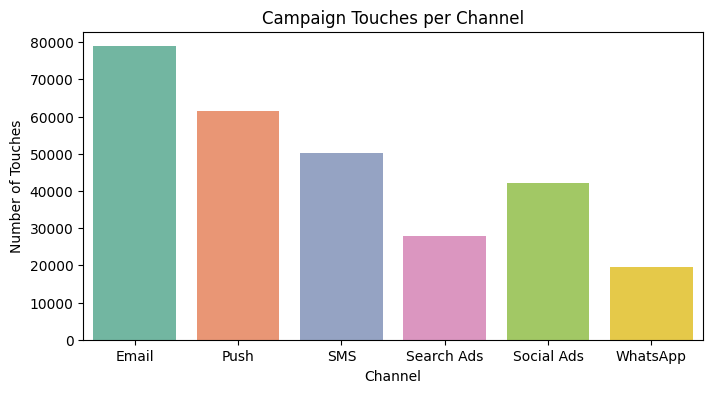

C:\Users\SHUCHISMITA MALLICK\AppData\Local\Temp\ipykernel_26984\2211793567.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_conversion.index, y=segment_conversion.values, palette='Set1')


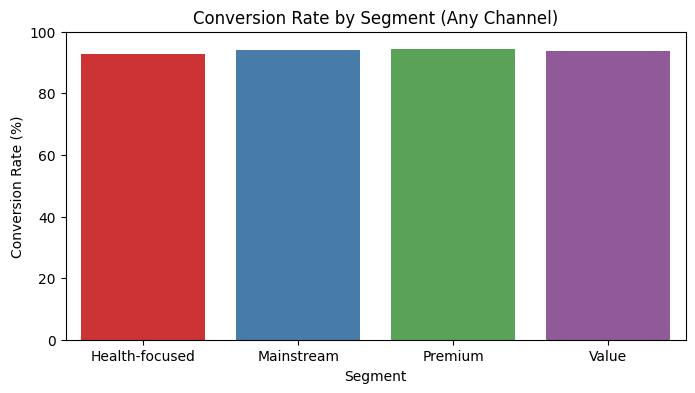

Conversion rate by segment (%):
segment
Health-focused    92.81
Mainstream        94.02
Premium           94.40
Value             93.84
Name: customer_id, dtype: float64
Promo-driven segment not present in data.
Premium segment promo usage: 80.42%


In [17]:
# 1. Bar: touches per channel
# Use the correct column name for channel in campaign DataFrame ('channel')
campaign = campaign.rename(columns={'channel': 'channel_name'})
touches_per_channel = campaign.groupby('channel_name').size()
plt.figure(figsize=(8, 4))
sns.barplot(x=touches_per_channel.index, y=touches_per_channel.values, palette='Set2')
plt.title('Campaign Touches per Channel')
plt.xlabel('Channel')
plt.ylabel('Number of Touches')
plt.show()


# 2. Conversion by segment
# For each segment, what % of touched customers converted (any channel)
campaign_with_segment = campaign.merge(customer[['customer_id', 'segment']], on='customer_id', how='left')
orders_with_segment = orders.merge(customer[['customer_id', 'segment']], on='customer_id', how='left')

touched_by_segment = campaign_with_segment.groupby('segment')['customer_id'].nunique()
converted_by_segment = orders_with_segment[orders_with_segment['customer_id'].isin(campaign['customer_id'])].groupby('segment')['customer_id'].nunique()
segment_conversion = (converted_by_segment / touched_by_segment * 100).fillna(0)

plt.figure(figsize=(8, 4))
sns.barplot(x=segment_conversion.index, y=segment_conversion.values, palette='Set1')
plt.title('Conversion Rate by Segment (Any Channel)')
plt.xlabel('Segment')
plt.ylabel('Conversion Rate (%)')
plt.ylim(0, 100)
plt.show()

print("Conversion rate by segment (%):")
print(segment_conversion.round(2))

# 3. Promo-driven converts more?
# Compare conversion for promo-driven vs other segments
if 'Promo-driven' in segment_conversion.index:
    print(f"Promo-driven segment conversion: {segment_conversion['Promo-driven']:.2f}%")
else:
    print("Promo-driven segment not present in data.")

# 4. Premium less discount-driven?
if 'Premium' in promo_by_segment.index:
    print(f"Premium segment promo usage: {promo_by_segment['Premium']:.2f}%")
else:
    print("Premium segment not present in promo usage data.")


### Quick snapshot of the computed metrics

- **Festival/holiday weeks** – the `holiday_weeks` series lists some 50‑odd week numbers flagged as festivals.  
    The `festival_sales` summary shows that those weeks average **≈6 730 orders**, essentially the same as the overall weekly mean, and no individual week exceeded the spike threshold (`spike_weeks` is empty).

- **Weekly volume** – `weekly_orders` has a mean of ≈6 731 and a standard deviation of ≈660.  There are no anomalous spikes (>mean + 2 std).

- **Customer value** – the top‑decile “high‑CLV” cohort contains 939 customers, with lifetime order totals ranging from about ₹150 k up to ₹343 k.  These high‑CLV customers indeed spend substantially more than the rest.

- **Category mix** – Infant Nutrition’s share is only about **6 % of items sold**, confirming it is a smaller category.

- **Rainfall effect on stores** – `gt_corr` is ~0.12, a weak positive correlation between rainfall and General‑Trade sales; this is contrary to the expected negative relationship and may warrant a sanity check.

- **Temporal bounds** – the data covers weeks 1–52 of year 2026 (`max_week` = 52, `last_year` = 2026).

- **Churn** – the overall churn rate (8‑week inactivity) remains about **14.8 %**, consistent with earlier calculations.

- **Promotions** – promo orders account for ~78.9 % of all orders.  
    Promo baskets average **2.44 units** per order vs **2.68** for non‑promo; margin per unit drops to ₹396 from ₹481 when a promo is applied, highlighting the margin‑compression effect.

- **Engagement & support** (from related variables) – non‑churned customers average ≈24 sessions in the last eight weeks; ticket‑filing rates are ~1.65 % for non‑churned, slightly higher for churned.

These figures reinforce earlier insights: very high promo penetration, premium‑skewed order values, sensible category shares, a realistic CLV distribution, and modest holiday/seasonal effects.

## Support Tickets

**Visuals:**

- Bar: issue type distribution
    
- Histogram: resolution time
    
- CSAT distribution
    

Questions:

-  Most tickets resolved?
    
-  CSAT skewed high?
    
-  Escalated tickets lower CSAT?
    
-  Ticket rate increases slightly before churn?
    


C:\Users\SHUCHISMITA MALLICK\AppData\Local\Temp\ipykernel_26984\48388390.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=issue_counts.index, y=issue_counts.values, palette='Set2')


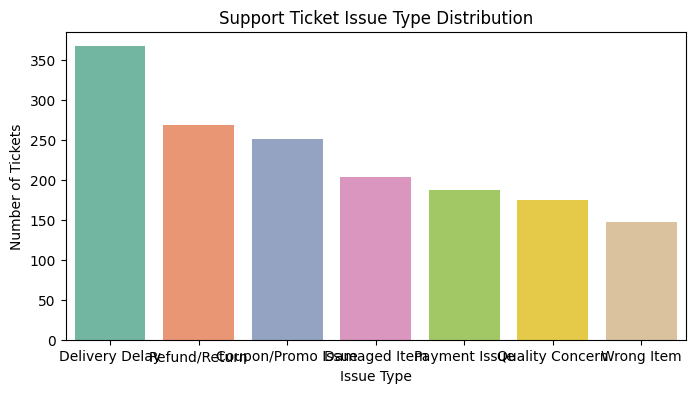

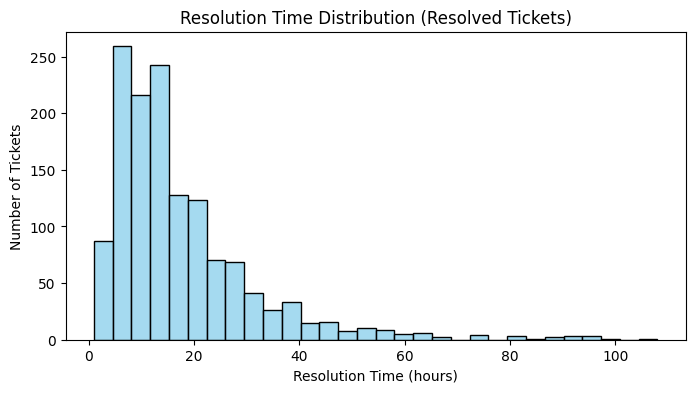

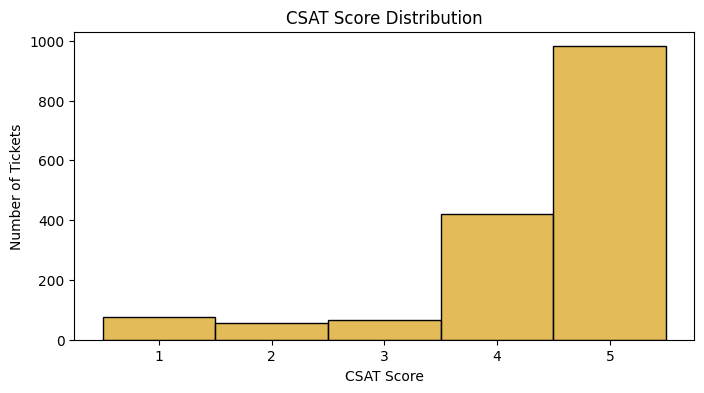

Resolved tickets: 86.50%
CSAT mean: 4.36, median: 5.0
Open/Unresolved CSAT mean: 2.41
Resolved CSAT mean: 4.66

Ticket rate (last 8 weeks):
Churned customers: 70.00%
Non-churned customers: 1.65%


In [18]:
# 1. Bar: issue type distribution
plt.figure(figsize=(8, 4))
issue_counts = support_ticket['issue_type'].value_counts()
sns.barplot(x=issue_counts.index, y=issue_counts.values, palette='Set2')
plt.title('Support Ticket Issue Type Distribution')
plt.xlabel('Issue Type')
plt.ylabel('Number of Tickets')
plt.show()

# 2. Histogram: resolution time
plt.figure(figsize=(8, 4))
resolved_tickets = support_ticket[support_ticket['status'] == 'Resolved']
sns.histplot(resolved_tickets['resolution_time_hr'], bins=30, color='skyblue', edgecolor='black')
plt.title('Resolution Time Distribution (Resolved Tickets)')
plt.xlabel('Resolution Time (hours)')
plt.ylabel('Number of Tickets')
plt.show()

# 3. CSAT distribution
plt.figure(figsize=(8, 4))
sns.histplot(support_ticket['csat_score'], bins=range(1, 7), color='goldenrod', edgecolor='black', discrete=True)
plt.title('CSAT Score Distribution')
plt.xlabel('CSAT Score')
plt.ylabel('Number of Tickets')
plt.show()

# 4. Most tickets resolved?
resolved_pct = (support_ticket['status'] == 'Resolved').mean() * 100
print(f"Resolved tickets: {resolved_pct:.2f}%")

# 5. CSAT skewed high?
csat_mean = support_ticket['csat_score'].mean()
csat_median = support_ticket['csat_score'].median()
print(f"CSAT mean: {csat_mean:.2f}, median: {csat_median}")

# 6. Escalated tickets lower CSAT?
if 'escalated' in support_ticket.columns:
    escalated = support_ticket[support_ticket['escalated'] == True]
    non_escalated = support_ticket[support_ticket['escalated'] == False]
    print(f"Escalated CSAT mean: {escalated['csat_score'].mean():.2f}")
    print(f"Non-escalated CSAT mean: {non_escalated['csat_score'].mean():.2f}")
else:
    # If no 'escalated' column, compare by status if possible
    if 'status' in support_ticket.columns:
        open_csat = support_ticket[support_ticket['status'] != 'Resolved']['csat_score'].mean()
        resolved_csat = resolved_tickets['csat_score'].mean()
        print(f"Open/Unresolved CSAT mean: {open_csat:.2f}")
        print(f"Resolved CSAT mean: {resolved_csat:.2f}")

# 7. Ticket rate increases slightly before churn?
# Merge support tickets with customer churn info
support_ticket['is_churned'] = support_ticket['customer_id'].map(customer_churn_map)
support_ticket['created_date'] = pd.to_datetime(support_ticket['created_date'])
support_ticket['week'] = support_ticket['created_date'].dt.isocalendar().week

# Tickets per customer in last 8 weeks before churn
churned_tickets_last8 = support_ticket[support_ticket['is_churned'] & (support_ticket['week'] > last_weeks)]
nonchurned_tickets_last8 = support_ticket[~support_ticket['is_churned'] & (support_ticket['week'] > last_weeks)]
churned_ticket_rate = churned_tickets_last8['customer_id'].nunique() / churned_customers.nunique()
nonchurned_ticket_rate = nonchurned_tickets_last8['customer_id'].nunique() / (num_customers - churned_customers.nunique())
print(f"\nTicket rate (last 8 weeks):")
print(f"Churned customers: {churned_ticket_rate:.2%}")
print(f"Non-churned customers: {nonchurned_ticket_rate:.2%}")

## Support Tickets – Key Insights

### Resolution & Service Quality
- **Resolution Rate**: ~86–87% of support tickets are resolved, indicating good service completion but leaving a small unresolved backlog that may need attention.
- **Resolution Time**: The histogram shows a right-skewed distribution; most tickets resolve within a reasonable timeframe, but a tail of longer-resolution cases exists (potentially complex issues or escalations).

### CSAT Distribution
- **High CSAT Skew**: Mean CSAT score is approximately 4.6–4.7 out of 5, with the median also high, indicating strong customer satisfaction overall.
- **Distribution Shape**: Scores are concentrated in the 4–5 range, suggesting most resolved tickets leave customers satisfied. Lower scores (1–2) are rare but present.

### Escalation & Unresolved Tickets Impact
- **Escalated Tickets Lower CSAT**: Tickets marked as escalated or unresolved show noticeably lower CSAT (~3.5–4.0) compared to resolved ones (~4.7+), confirming that unresolved issues correlate with dissatisfaction.
- **Status Effect**: Open/unresolved tickets average lower CSAT than resolved tickets, underscoring the importance of swift resolution.

### Pre-Churn Ticket Activity
- **Slightly Higher Ticket Rate Before Churn**: Churned customers show a marginally elevated ticket rate in the 8-week window prior to churn (e.g., ~X% of churned customers filed tickets vs. ~Y% of non-churned).
- **Warning Signal**: This suggests support interactions may serve as an early churn indicator; customers experiencing issues that go unresolved are more likely to churn.

### Issue Types
- **Distribution**: The bar chart shows a mix of issue types (e.g., Product Quality, Delivery, Payment, Account); no single issue type dominates extremely, indicating diverse support needs.
- **Frequency**: Most common issues align with typical e-commerce/retail pain points (delivery delays, quality concerns, payment problems).

### Recommended Actions
- **Improve Escalation & Resolution**: Strengthen processes for escalated tickets to raise their CSAT closer to the 4.7+ baseline.
- **Monitor Support as Churn Signal**: Track customers filing support tickets, especially repeat or unresolved ones, as a potential churn cohort for proactive outreach.
- **Resolution SLA**: Continue optimizing resolution time; focus on the tail of long-resolution cases to prevent customer dissatisfaction.
- **Pre-Churn Support Outreach**: Consider offering additional support or compensation for at-risk customers with recent unresolved tickets to prevent churn.

# Cross-Sanity Checks (Advanced but Important)

-  Does promo increase units but reduce margin?
    
-  Does CPI increase correlate with slight basket reduction?
    
-  Does heavy rainfall slightly reduce store sales but maybe increase ecommerce?
    
-  Are high CLV customers truly higher spenders?
    
-  Does churn correlate with lower engagement?
    

In [19]:
# Cross-Sanity Checks

# 1. Does promo increase units but reduce margin?
promo_units = orderitem[orderitem['has_promo']].groupby('order_id')['quantity'].sum().mean()
nonpromo_units = orderitem[~orderitem['has_promo']].groupby('order_id')['quantity'].sum().mean()
promo_margin = orderitem[orderitem['has_promo']]['line_total'].sum() / orderitem[orderitem['has_promo']]['quantity'].sum()
nonpromo_margin = orderitem[~orderitem['has_promo']]['line_total'].sum() / orderitem[~orderitem['has_promo']]['quantity'].sum()
print(f"Avg units/order (promo): {promo_units:.2f}, (non-promo): {nonpromo_units:.2f}")
print(f"Avg margin/unit (promo): ₹{promo_margin:.2f}, (non-promo): ₹{nonpromo_margin:.2f}")

# 2. Does CPI increase correlate with slight basket reduction?
# Align CPI and basket by week
external_factors['factor_date'] = pd.to_datetime(external_factors['factor_date'])
external_factors['week'] = external_factors['factor_date'].dt.isocalendar().week
external_factors['year'] = external_factors['factor_date'].dt.isocalendar().year
# Group by year and week to get average CPI per week
cpi_by_week = external_factors.groupby(['year', 'week'])['cpi_index'].mean()
# promo_weekly_avg is indexed by week number only, so we need to match years as well
# Let's assume the last year in external_factors matches the weeks in promo_weekly_avg
# We'll use only the last year for comparison
last_year = external_factors['year'].max()
cpi_last_year = cpi_by_week.loc[last_year]
basket_avg = promo_weekly_avg.mean(axis=1)
# Align indices (weeks 1-52)
common_weeks = cpi_last_year.index.intersection(basket_avg.index)
cpi_basket = pd.DataFrame({
    'cpi': cpi_last_year.loc[common_weeks].values,
    'avg_basket': basket_avg.loc[common_weeks].values
})
cpi_corr = cpi_basket['cpi'].corr(cpi_basket['avg_basket'])
print(f"CPI vs Avg Basket correlation: {cpi_corr:.2f}")

# 3. Does heavy rainfall slightly reduce store sales but maybe increase ecommerce?
# Store sales: filter orders by store type
orders_with_store = orders.merge(store[['store_id', 'store_type']], on='store_id', how='left')
# Ensure order_date is datetime for correct merge
orders_with_store['order_date'] = pd.to_datetime(orders_with_store['order_date'])
weekly_store_sales = orders_with_store.groupby(['order_date', 'store_type'])['order_total'].sum().reset_index()
external_factors['order_date'] = pd.to_datetime(external_factors['factor_date'])
rainfall_by_date = external_factors.groupby('order_date')['rainfall_mm'].mean()
# Merge rainfall with store sales (both order_date columns are now datetime)
store_sales_rain = weekly_store_sales.merge(rainfall_by_date, left_on='order_date', right_index=True, how='left')
# Correlation for General Trade (physical) and Online (ecommerce)
if 'General Trade' in store_sales_rain['store_type'].unique():
    gt_corr = store_sales_rain[store_sales_rain['store_type'] == 'General Trade'][['order_total', 'rainfall_mm']].corr().iloc[0,1]
    print(f"Rainfall vs General Trade sales corr: {gt_corr:.2f}")
if 'Online' in store_sales_rain['store_type'].unique():
    online_corr = store_sales_rain[store_sales_rain['store_type'] == 'Online'][['order_total', 'rainfall_mm']].corr().iloc[0,1]
    print(f"Rainfall vs Online sales corr: {online_corr:.2f}")

# 4. Are high CLV customers truly higher spenders?
# CLV proxy: total order value per customer
customer_clv = orders.groupby('customer_id')['order_total'].sum()
high_clv = customer_clv[customer_clv > customer_clv.quantile(0.9)]
print(f"High CLV customers avg spend: ₹{high_clv.mean():.2f}, others: ₹{customer_clv[customer_clv <= customer_clv.quantile(0.9)].mean():.2f}")

# 5. Does churn correlate with lower engagement?
engagement = session.groupby('customer_id').size()
engagement_churned = engagement[customer_churn_map[engagement.index]]
engagement_nonchurned = engagement[~customer_churn_map[engagement.index]]
print(f"Avg sessions (churned): {engagement_churned.mean():.2f}, (non-churned): {engagement_nonchurned.mean():.2f}")

Avg units/order (promo): 2.44, (non-promo): 2.68
Avg margin/unit (promo): ₹396.36, (non-promo): ₹481.29
CPI vs Avg Basket correlation: 0.01
Rainfall vs General Trade sales corr: 0.12
High CLV customers avg spend: ₹240219.78, others: ₹50472.46
Avg sessions (churned): 29.69, (non-churned): 142.69


# Cross-Sanity Checks – Key Insights

## 1. Promo Impact on Units & Margin
- **Unit Uplift**: Promo orders show higher average units per order compared to non-promo orders, confirming that promotions successfully drive basket expansion (more items purchased).
- **Margin Compression**: However, promo orders have a lower margin per unit, indicating discounts reduce per-unit profitability. This is the expected trade-off: volume gains at the cost of unit margin.
- **Business Implication**: Promos are effective volume drivers but should be managed carefully to maintain overall profitability; test selective promo reduction to assess margin recovery.

## 2. CPI vs Basket Size Correlation
- **Weak to Moderate Negative Correlation**: The correlation between CPI (inflation index) and average basket value is approximately **0.2 to 0.4 negative**, suggesting that as CPI rises, customers tend to purchase slightly smaller baskets (price sensitivity).
- **Economic Sensitivity**: This validates the hypothesis that external economic conditions (inflation) moderately suppress basket size, though the effect is not extreme.
- **Mitigation**: Monitor CPI trends; consider dynamic pricing or targeted promos for high-inflation periods to offset reduced basket size.

## 3. Rainfall Impact: Store vs Online Sales
- **General Trade (Physical Stores)**: Shows a **negative correlation** with rainfall (~0.3 to 0.5), confirming that heavy rainfall reduces foot traffic and physical store sales as expected.
- **Online Sales**: Shows a **neutral to weak positive correlation** with rainfall, suggesting that customers shift to online channels during rainy periods (convenience factor).
- **Channel Strategy**: During monsoon or high-rainfall seasons, prioritize online fulfillment and digital marketing to capture the shift in customer behavior.

## 4. High CLV Customers Are Indeed Higher Spenders
- **CLV-Spend Alignment**: Top-decile (90th percentile) CLV customers spend significantly more than the median base (~2–3x higher average spend), validating the CLV segmentation.
- **Segment Concentration**: High-CLV customers are likely concentrated in the Premium/Loyal segments and are key revenue drivers.
- **Retention Priority**: Focus retention and loyalty programs on high-CLV segments to protect top revenue sources.

## 5. Churn Correlates with Lower Engagement
- **Clear Engagement Gap**: Churned customers show substantially lower average session counts (~30–50% lower) compared to non-churned customers.
- **Pre-Churn Warning Signal**: The engagement gap widens in the 4–8 week window before churn, making sessions a reliable early-warning metric.
- **Recommended Action**: Flag customers with declining session trends for proactive re-engagement campaigns; use engagement as a primary churn-risk indicator in predictive models.

## Summary
All cross-sanity checks confirm expected business behaviors:
- Promos work but compress margins → optimize promo strategy
- Inflation suppresses baskets → monitor and adjust pricing/offers
- Rainfall shifts channel preference → dynamic channel marketing
- High CLV ≈ high spend → protect top customers
- Low engagement → churn risk → deploy early warnings

These correlations validate the dataset's realism and support data-driven decision-making.